In [11]:
# ===============================
# 0. Dependencies & Setup
# ===============================
import torch
import sys

TORCH_VER = torch.__version__

# Optional C++ extensions — skip gracefully if no matching wheel exists
try:
    import subprocess

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv",
        "-f", f"https://data.pyg.org/whl/torch-{TORCH_VER}.html"
    ], check=True)

    print("Optional PyG C++ extensions installed.")

except Exception as e:
    print(f"[INFO] Optional PyG C++ extensions unavailable (safe to ignore): {e}")


# Core required packages
import subprocess
import sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch_geometric",
    "matplotlib",
    "tqdm",
    "scikit-learn",
    "transformers",
    "librosa",
    "soundfile",
    "torchvision",
    "pillow",
    "opencv-python-headless"
], check=False)


import os
import json
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
from tqdm import tqdm


# ── CONFIGURATION ─────────────────────────────────────────────────────────────

BASE_PATH = '/content/drive/MyDrive/MultiModal_Sarcasm_Detection/BTP_DATASET/'  # UPDATE to exact folder name

# MUStARD raw dataset paths
MUSTARD_JSON = os.path.join(BASE_PATH, 'sarcasm_data.json')
UTTERANCE_DIR = os.path.join(
    BASE_PATH,
    'Utterance/Utterance_Videos/'
)  # {id}.mp4

CONTEXT_DIR = os.path.join(
    BASE_PATH,
    'Context/Context_Videos/'
)  # {id}_c.mp4


# Pre-computed feature files (produced by extraction cells, loaded in Cell 8)
TEXT_FEAT = 'text_features_imp.npy'
AUDIO_FEAT = 'audio_features_imp.npy'
VIDEO_FEAT = 'video_features_imp.npy'
CONTEXT_FEAT = 'context_features_imp.npy'
LABELS_FEAT = 'labels_imp.npy'
IDS_FEAT = 'sample_ids_imp.npy'


# ── FFT-guided HuBERT audio config (identical to simple_fft notebook) ────────

HUBERT_NAME = 'facebook/hubert-large-ls960-ft'
HUBERT_DIM = 1024
AUDIO_DIM = HUBERT_DIM * 2  # 2048-d: focused(1024) + global(1024)

FFT_FEAT_DIR = os.path.join(BASE_PATH, 'features_fft/')
MAX_FRAMES = 512              # max FFT weight frames stored per sample
FFT_TEMP = 5.0                # temperature for softmax frame attention


# ── CLIP ViT-L/14 video config (replaces ResNet-50) ──────────────────────────

CLIP_NAME = 'openai/clip-vit-large-patch14'
CLIP_DIM = 768                # CLIP ViT-L/14 projected image-embedding dim


# ── Force re-extraction of VIDEO (+ dependent CONTEXT) features ──────────────
#
# Set True whenever the video backbone changes (as it just did:
# ResNet-50 → CLIP ViT-L/14) so Cells 6–7 regenerate
# video_features_imp.npy / video_context_features.npy /
# context_features_imp.npy instead of silently reusing old cached .npy files
# still sitting in BASE_PATH.
#
# Safe to flip back to False once you have re-run extraction once
# with the new backbone.

FORCE_VIDEO_REEXTRACT = True


# ── Training hyper-parameters ─────────────────────────────────────────────────

BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 10


# ── Device ────────────────────────────────────────────────────────────────────

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')

Optional PyG C++ extensions installed.
Using device: cuda


In [12]:
 # ===============================
    # 1. Mount Google Drive
    # ===============================
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [13]:
# ===============================
# 2. Dataset Verification
# Structure:
#   Utterance/{id}.mp4    — utterance video + audio
#   Context/{id}_c.mp4    — context video + audio (_c suffix)
#   sarcasm_data.json     — labels + utterance text
# ===============================
print('=' * 60)
print('MUSTARD DATASET VERIFICATION')
print('=' * 60)

MUSTARD DATASET VERIFICATION


In [14]:
# ── 2a. Check JSON ────────────────────────────────────────────────────────────
assert os.path.isfile(MUSTARD_JSON), f'JSON not found: {MUSTARD_JSON}'
with open(MUSTARD_JSON, 'r') as f:
    raw_data = json.load(f)

all_ids = list(raw_data.keys())
print(f'\n[JSON] Loaded : {len(all_ids)} entries from sarcasm_data.json')
print(f'  Sarcastic: {sum(1 for v in raw_data.values() if v["sarcasm"])}')
print(f'  Non-sarc : {sum(1 for v in raw_data.values() if not v["sarcasm"])}')

sample_key = all_ids[0]
print(f'\n[JSON] Sample key : {sample_key!r}')
print(f'  Fields : {list(raw_data[sample_key].keys())}')
print(f'  Sample utterance: {str(raw_data[sample_key].get("utterance", "N/A"))[:80]}')

    # ── 2b. Check folders ─────────────────────────────────────────────────────────
assert os.path.isdir(UTTERANCE_DIR), f'Utterance folder not found: {UTTERANCE_DIR}'
assert os.path.isdir(CONTEXT_DIR), f'Context folder not found: {CONTEXT_DIR}'

utt_files = set(os.listdir(UTTERANCE_DIR))
ctx_files = set(os.listdir(CONTEXT_DIR))

print(f'\n[DIR] Utterance/ : {len(utt_files)} files total')
print(f'[DIR] Context/   : {len(ctx_files)} files total')

    # ── 2c. Per-ID presence check ─────────────────────────────────────────────────
    # Utterance/{id}.mp4 vs Context/{id}_c.mp4
status = {}
for uid in all_ids:
    status[uid] = {
        'utterance_video': f'{uid}.mp4' in utt_files,
        'context_video'  : f'{uid}_c.mp4' in ctx_files,
    }

n_utt = sum(1 for s in status.values() if s['utterance_video'])
n_ctx = sum(1 for s in status.values() if s['context_video'])
n_all = sum(1 for s in status.values() if s['utterance_video'] and s['context_video'])

print('\n' + '-' * 60)
print('FILE PRESENCE COUNTS')
print(f'  Total entries in JSON        : {len(all_ids)}')
print(f'  Utterance/{"{id}"}.mp4 found   : {n_utt}')
print(f'  Context/{"{id}"}_c.mp4 found   : {n_ctx}')
print(f'  Fully linked (both present)  : {n_all}')
print(f'  Missing at least one modality: {len(all_ids) - n_all}')

    # ── 2d. Report missing files ──────────────────────────────────────────────────
missing_utt = [uid for uid, s in status.items() if not s['utterance_video']]
missing_ctx = [uid for uid, s in status.items() if not s['context_video']]

if missing_utt:
    print(f'\n[WARN] {len(missing_utt)} utterance video(s) MISSING in Utterance/:')
    for uid in missing_utt[:10]: print(f'  {uid}.mp4')
    if len(missing_utt) > 10: print(f'  ... and {len(missing_utt)-10} more')
else:
    print('\n[OK] All utterance videos present in Utterance/.')

if missing_ctx:
    print(f'\n[WARN] {len(missing_ctx)} context video(s) MISSING in Context/:')
    for uid in missing_ctx[:10]: print(f'  {uid}_c.mp4')
    if len(missing_ctx) > 10: print(f'  ... and {len(missing_ctx)-10} more')
else:
        print('[OK] All context videos present in Context/.')

    # ── 2e. Build working set of fully-linked IDs ─────────────────────────────────
valid_ids = [
    uid for uid in all_ids
    if status[uid]['utterance_video'] and status[uid]['context_video']
]
print(f'\n[INFO] Working set for feature extraction: {len(valid_ids)} samples')
print('=' * 60)


[JSON] Loaded : 690 entries from sarcasm_data.json
  Sarcastic: 345
  Non-sarc : 345

[JSON] Sample key : '1_60'
  Fields : ['utterance', 'speaker', 'context', 'context_speakers', 'show', 'sarcasm']
  Sample utterance: It's just a privilege to watch your mind at work.

[DIR] Utterance/ : 690 files total
[DIR] Context/   : 690 files total

------------------------------------------------------------
FILE PRESENCE COUNTS
  Total entries in JSON        : 690
  Utterance/{id}.mp4 found   : 690
  Context/{id}_c.mp4 found   : 690
  Fully linked (both present)  : 690
  Missing at least one modality: 0

[OK] All utterance videos present in Utterance/.
[OK] All context videos present in Context/.

[INFO] Working set for feature extraction: 690 samples


In [15]:
# ===============================
# 3. Check Pre-computed Features
# Skip extraction if all .npy files already exist.
# ===============================

feat_files = {
    'text': os.path.join(BASE_PATH, TEXT_FEAT),
    'audio': os.path.join(BASE_PATH, AUDIO_FEAT),
    'video': os.path.join(BASE_PATH, VIDEO_FEAT),
    'context': os.path.join(BASE_PATH, CONTEXT_FEAT),
    'labels': os.path.join(BASE_PATH, LABELS_FEAT),
}

feats_exist = {k: os.path.isfile(v) for k, v in feat_files.items()}
all_feats_exist = all(feats_exist.values())

print('Feature file status:')

for name, path in feat_files.items():
    tick = '[OK]     ' if feats_exist[name] else '[MISSING]'
    print(f'  {tick} {os.path.basename(path)}')

if all_feats_exist:
    print('\nAll feature files found — skipping extraction (jump to Cell 8).')
else:
    missing = [k for k, v in feats_exist.items() if not v]
    print(f'\nMissing: {missing}')
    print('Proceeding to feature extraction (Cells 4–7)...')

RUN_EXTRACTION = not all_feats_exist


# ── Video backbone swapped (ResNet-50 → CLIP ViT-L/14) ─────────────────────────
# Cells 6 (video) and 7 (context, which depends on video) must re-run even
# when RUN_EXTRACTION is False and old .npy files already exist on disk,
# otherwise stale ResNet-50 features would be silently reused.

RUN_VIDEO_EXTRACTION = RUN_EXTRACTION or FORCE_VIDEO_REEXTRACT

if FORCE_VIDEO_REEXTRACT and not RUN_EXTRACTION:
    print(
        '[INFO] FORCE_VIDEO_REEXTRACT=True → Cells 6-7 will re-run with '
        'CLIP ViT-L/14 even though cached video/context .npy files exist.'
    )

Feature file status:
  [MISSING] text_features_imp.npy
  [MISSING] audio_features_imp.npy
  [MISSING] video_features_imp.npy
  [MISSING] context_features_imp.npy
  [MISSING] labels_imp.npy

Missing: ['text', 'audio', 'video', 'context', 'labels']
Proceeding to feature extraction (Cells 4–7)...


In [16]:
# ===============================
# 4. Text Feature Extraction
# Model  : roberta-base → 768-dim CLS token
# Source : 'utterance' field in sarcasm_data.json
# Output : text_features_imp.npy (N × 768)
# ===============================

# ── Safety guard: rebuild valid_ids / raw_data if Cell 2 was skipped ──────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():
    print("[INFO] valid_ids not in scope — rebuilding from sarcasm_data.json...")

    assert os.path.isfile(MUSTARD_JSON), f"JSON not found: {MUSTARD_JSON}"

    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)

    all_ids = list(raw_data.keys())

    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))

    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4' in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]

    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")


if not RUN_EXTRACTION:
    print("Skipping text extraction (features already exist).")

else:
    import warnings

    warnings.filterwarnings("ignore")

    from transformers import (
        RobertaTokenizer,
        RobertaModel,
        logging as hf_logging
    )

    hf_logging.set_verbosity_error()

    print("Loading RoBERTa-base for text feature extraction...")

    tokenizer_txt = RobertaTokenizer.from_pretrained(
        'roberta-base'
    )

    model_txt = RobertaModel.from_pretrained(
        'roberta-base',
        add_pooling_layer=False
    ).to(DEVICE)

    model_txt.eval()

    print(
        f"Model loaded. Extracting features for "
        f"{len(valid_ids)} samples..."
    )

    text_features = []

    with torch.no_grad():
        for uid in tqdm(valid_ids, desc='Text'):

            utterance_text = raw_data[uid]['utterance']

            enc = tokenizer_txt(
                utterance_text,
                return_tensors='pt',
                max_length=128,
                truncation=True,
                padding='max_length'
            ).to(DEVICE)

            out = model_txt(**enc)

            # CLS token → (768,)
            feat = (
                out.last_hidden_state[:, 0, :]
                .squeeze(0)
                .cpu()
                .numpy()
            )

            text_features.append(feat)

    text_features = np.array(text_features)  # (N, 768)

    np.save(
        os.path.join(BASE_PATH, TEXT_FEAT),
        text_features
    )

    print(
        f"Text features saved: "
        f"{text_features.shape} → {TEXT_FEAT}"
    )

    del model_txt, tokenizer_txt
    torch.cuda.empty_cache()

Loading RoBERTa-base for text feature extraction...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Model loaded. Extracting features for 690 samples...


Text: 100%|██████████| 690/690 [00:07<00:00, 94.96it/s] 

Text features saved: (690, 768) → text_features_imp.npy


In [17]:
# ===============================
# 5. Audio Feature Extraction (FFT-Guided HuBERT)
# Utterance : Utterance/{id}.mp4  → FFT-weighted HuBERT-large → 2048-dim
# Context   : Context/{id}_c.mp4  → FFT-weighted HuBERT-large → 2048-dim
#
# FFT frame weights:
#   Pitch F0             weight 0.40
#   Spectral flux        weight 0.25
#   Spectral centroid    weight 0.20
#   RMS energy           weight 0.15
#
# Used as softmax attention over HuBERT hidden states.
#
# Each output = concat([focused_1024, global_1024]) → 2048-d
#
# Outputs:
#   audio_features_imp.npy        (N × 2048)  — utterance audio
#   audio_context_features.npy    (N × 2048)  — context audio
# ===============================


# ── Safety guard ──────────────────────────────────────────────────────────────
if 'valid_ids' not in dir() or 'raw_data' not in dir():

    print("[INFO] valid_ids not in scope — rebuilding...")

    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)

    all_ids = list(raw_data.keys())

    utt_files = set(os.listdir(UTTERANCE_DIR))
    ctx_files = set(os.listdir(CONTEXT_DIR))

    valid_ids = [
        uid for uid in all_ids
        if f'{uid}.mp4' in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]

    print(f"[INFO] Rebuilt valid_ids: {len(valid_ids)} samples.")


# ── Run / Skip extraction ─────────────────────────────────────────────────────

if not RUN_EXTRACTION:

    print("Skipping audio extraction (features already exist).")

else:

    import io
    import librosa
    import soundfile as sf
    import subprocess as sp
    import tempfile
    import warnings

    warnings.filterwarnings("ignore")

    from transformers import (
        HubertModel,
        Wav2Vec2FeatureExtractor,
        logging as hf_logging
    )

    hf_logging.set_verbosity_error()

    os.makedirs(FFT_FEAT_DIR, exist_ok=True)

    SAMPLE_RATE = 16_000  # HuBERT expects 16 kHz


    # ── Step 1: Waveform extraction from video file ───────────────────────────

    def extract_wav_from_video(
        video_path: str,
        sr: int = SAMPLE_RATE
    ) -> np.ndarray:
        """
        Extract mono waveform from an mp4/video file via ffmpeg.
        """

        with tempfile.NamedTemporaryFile(
            suffix='.wav',
            delete=False
        ) as tmp:

            tmp_path = tmp.name

        try:
            sp.run(
                [
                    'ffmpeg',
                    '-y',
                    '-i',
                    video_path,
                    '-ac',
                    '1',
                    '-ar',
                    str(sr),
                    '-vn',
                    tmp_path
                ],
                stdout=sp.DEVNULL,
                stderr=sp.DEVNULL,
                check=True
            )

            audio, _ = librosa.load(
                tmp_path,
                sr=sr,
                mono=True
            )

            return audio.astype(np.float32)

        finally:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)


    # ── Step 2: FFT-derived per-frame expressiveness weights ──────────────────

    def get_sarcasm_frame_weights(
        y: np.ndarray,
        sr: int = SAMPLE_RATE,
        hop_length: int = 512
    ) -> np.ndarray:
        """
        Compute per-frame expressiveness scores using FFT-derived features.

        Returns:
            normalized weights (n_frames,)
            where high = likely sarcastic cue.
        """

        # 1. Pitch F0
        try:

            f0, _, _ = librosa.pyin(
                y,
                fmin=50,
                fmax=500,
                sr=sr,
                hop_length=hop_length
            )

            f0 = np.nan_to_num(
                f0,
                nan=0.0
            )

        except Exception:

            f0 = np.zeros(
                1 + len(y) // hop_length
            )


        # 2. RMS energy
        rms = librosa.feature.rms(
            y=y,
            hop_length=hop_length
        )[0]


        # 3. Spectral flux (FFT-based)
        stft = np.abs(
            librosa.stft(
                y,
                hop_length=hop_length,
                n_fft=1024
            )
        )

        flux = np.sqrt(
            np.sum(
                np.diff(stft, axis=1) ** 2,
                axis=0
            )
        )

        flux = np.pad(
            flux,
            (1, 0)
        )


        # 4. Spectral centroid
        centroid = librosa.feature.spectral_centroid(
            y=y,
            sr=sr,
            hop_length=hop_length
        )[0]


        # Align all features to shortest length
        min_len = min(
            len(f0),
            len(rms),
            len(flux),
            len(centroid)
        )

        f0 = f0[:min_len]
        rms = rms[:min_len]
        flux = flux[:min_len]
        centroid = centroid[:min_len]


        # Normalize to [0, 1]
        def norm01(x: np.ndarray) -> np.ndarray:

            r = x.max() - x.min()

            if r > 1e-8:
                return (x - x.min()) / r

            return np.zeros_like(x)


        # Weighted expressiveness score
        score = (
            norm01(f0) * 0.40
            + norm01(flux) * 0.25
            + norm01(centroid) * 0.20
            + norm01(rms) * 0.15
        )

        return score.astype(np.float32)


    # ── Step 3: Load HuBERT-large ─────────────────────────────────────────────

    print("Loading HuBERT-large feature extractor...")

    hubert_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
        HUBERT_NAME
    )

    print("Loading HuBERT-large model (frozen for pre-extraction)...")

    hubert_model = (
        HubertModel
        .from_pretrained(HUBERT_NAME)
        .float()
        .to(DEVICE)
        .eval()
    )

    print("HuBERT loaded.")


    # ── Step 4: FFT-weighted HuBERT encoding ──────────────────────────────────

    @torch.no_grad()
    def extract_fft_audio(
        waveform: np.ndarray,
        fft_w: np.ndarray,
        sr: int = SAMPLE_RATE
    ):
        """
        FFT-weighted HuBERT encoding.

        Returns:
            focused  (1024,) — FFT-attention-weighted mean
            global_  (1024,) — standard mean
        """

        inp = hubert_extractor(
            waveform,
            sampling_rate=sr,
            return_tensors='pt',
            padding=True
        )

        wav_tensor = inp['input_values'].to(
            DEVICE
        )

        out = hubert_model(
            wav_tensor,
            output_hidden_states=True
        )

        # Last 4 HuBERT layers
        last4 = torch.stack(
            out.hidden_states[-4:]
        ).mean(0)

        # (1, T_h, 1024)
        T_h = last4.shape[1]


        # Interpolate FFT weights to HuBERT resolution
        fft_tensor = (
            torch.tensor(
                fft_w,
                dtype=torch.float32
            )
            .unsqueeze(0)
            .unsqueeze(0)
            .to(DEVICE)
        )

        fft_aligned = F.interpolate(
            fft_tensor,
            size=T_h,
            mode='linear',
            align_corners=False
        ).squeeze()


        # Softmax with temperature
        attn = torch.softmax(
            fft_aligned * FFT_TEMP,
            dim=0
        )


        # FFT-attended weighted mean
        focused = (
            last4[0]
            * attn.unsqueeze(-1)
        ).sum(0)


        # Standard global mean
        global_ = last4[0].mean(0)


        return (
            focused.cpu().numpy(),
            global_.cpu().numpy()
        )


    # ── Step 5: Quick FFT test on first sample ────────────────────────────────

    _test_path = os.path.join(
        UTTERANCE_DIR,
        f'{valid_ids[0]}.mp4'
    )

    _y = extract_wav_from_video(
        _test_path
    )

    _w = get_sarcasm_frame_weights(
        _y,
        SAMPLE_RATE
    )

    print("\nFFT weight test:")

    print(
        f"  waveform      : "
        f"{len(_y)} samples "
        f"({len(_y) / SAMPLE_RATE:.2f}s)"
    )

    print(
        f"  frame weights : "
        f"{len(_w)} frames, "
        f"range=[{_w.min():.3f}, {_w.max():.3f}]"
    )

    print(
        f"  high-score frames (>0.7): "
        f"{(_w > 0.7).sum()}"
    )

    del _y, _w


    # ── Step 6: Pre-extract FFT-weighted HuBERT for all samples ──────────────

    print(
        f"\nExtracting FFT-guided HuBERT features "
        f"for {len(valid_ids)} samples..."
    )

    print(
        "(Utterance + Context — 2048-d each)"
    )


    audio_utt_features = np.zeros(
        (len(valid_ids), 2048),
        dtype=np.float32
    )

    audio_ctx_features = np.zeros(
        (len(valid_ids), 2048),
        dtype=np.float32
    )


    for idx, uid in enumerate(
        tqdm(
            valid_ids,
            desc='FFT-HuBERT (utt + ctx)'
        )
    ):

        # ── Utterance audio ───────────────────────────────────────────────────

        utt_path = os.path.join(
            UTTERANCE_DIR,
            f'{uid}.mp4'
        )

        try:

            y_utt = extract_wav_from_video(
                utt_path
            )

            w_utt = get_sarcasm_frame_weights(
                y_utt,
                SAMPLE_RATE
            )


            # Pad/truncate to MAX_FRAMES
            if len(w_utt) >= MAX_FRAMES:

                w_utt_fixed = w_utt[:MAX_FRAMES]

            else:

                w_utt_fixed = np.pad(
                    w_utt,
                    (0, MAX_FRAMES - len(w_utt))
                )


            focused_utt, global_utt = extract_fft_audio(
                y_utt,
                w_utt_fixed,
                SAMPLE_RATE
            )


            audio_utt_features[idx] = np.concatenate(
                [
                    focused_utt,
                    global_utt
                ]
            )

        except Exception as e:

            print(
                f'[WARN] Audio utt failed for {uid}: {e}'
            )

            # Zero vector remains in place


        # ── Context audio ─────────────────────────────────────────────────────

        ctx_path = os.path.join(
            CONTEXT_DIR,
            f'{uid}_c.mp4'
        )

        try:

            y_ctx = extract_wav_from_video(
                ctx_path
            )

            w_ctx = get_sarcasm_frame_weights(
                y_ctx,
                SAMPLE_RATE
            )


            if len(w_ctx) >= MAX_FRAMES:

                w_ctx_fixed = w_ctx[:MAX_FRAMES]

            else:

                w_ctx_fixed = np.pad(
                    w_ctx,
                    (0, MAX_FRAMES - len(w_ctx))
                )


            focused_ctx, global_ctx = extract_fft_audio(
                y_ctx,
                w_ctx_fixed,
                SAMPLE_RATE
            )


            audio_ctx_features[idx] = np.concatenate(
                [
                    focused_ctx,
                    global_ctx
                ]
            )

        except Exception as e:

            print(
                f'[WARN] Audio ctx failed for {uid}: {e}'
            )

            # Zero vector remains in place


    # ── Save features ─────────────────────────────────────────────────────────

    np.save(
        os.path.join(
            BASE_PATH,
            AUDIO_FEAT
        ),
        audio_utt_features
    )

    np.save(
        os.path.join(
            BASE_PATH,
            'audio_context_features.npy'
        ),
        audio_ctx_features
    )


    print(
        f"Utterance audio saved : "
        f"{audio_utt_features.shape} → {AUDIO_FEAT}"
    )

    print(
        f"Context audio saved   : "
        f"{audio_ctx_features.shape} → "
        f"audio_context_features.npy"
    )


    # ── Free HuBERT from GPU ──────────────────────────────────────────────────

    del hubert_model
    del hubert_extractor

    torch.cuda.empty_cache()


# ===============================
# 6. Video Feature Extraction
# Utterance : Utterance/{id}.mp4
#              → CLIP ViT-L/14 image encoder → 768-dim
#
# Context   : Context/{id}_c.mp4
#              → CLIP ViT-L/14 image encoder → 768-dim
#
# Model     : openai/clip-vit-large-patch14
#
# Strategy  : uniformly sample 8 frames, run each through CLIP's
#             vision tower + projection head, mean-pool → (768,)
#
# Outputs:
#   video_features_imp.npy        (N × 768)  — utterance video
#   video_context_features.npy    (N × 768)  — context video
# ===============================


# ── Safety guard ──────────────────────────────────────────────────────────────

if 'valid_ids' not in dir() or 'raw_data' not in dir():

    print("[INFO] valid_ids not in scope — rebuilding...")

    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)

    all_ids = list(raw_data.keys())

    utt_files = set(
        os.listdir(UTTERANCE_DIR)
    )

    ctx_files = set(
        os.listdir(CONTEXT_DIR)
    )

    valid_ids = [
        uid
        for uid in all_ids
        if f'{uid}.mp4' in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]

    print(
        f"[INFO] Rebuilt valid_ids: "
        f"{len(valid_ids)} samples."
    )


# ── Run / Skip video extraction ──────────────────────────────────────────────

if not RUN_VIDEO_EXTRACTION:

    print(
        "Skipping video extraction "
        "(features already exist)."
    )

else:

    import cv2
    import warnings

    warnings.filterwarnings("ignore")

    from transformers import (
        CLIPModel,
        CLIPImageProcessor,
        logging as hf_logging
    )

    hf_logging.set_verbosity_error()


    N_FRAMES = 8  # Uniform frame samples per clip


    # ── CLIP ViT-L/14 vision encoder ──────────────────────────────────────────

    print(
        "Loading CLIP ViT-L/14 "
        "for video feature extraction..."
    )

    clip_processor = (
        CLIPImageProcessor
        .from_pretrained(CLIP_NAME)
    )

    clip_model = (
        CLIPModel
        .from_pretrained(CLIP_NAME)
        .to(DEVICE)
        .eval()
    )

    print(
        f"CLIP loaded. "
        f"Image embedding dim: {CLIP_DIM}"
    )


    # ── Video feature extraction function ─────────────────────────────────────

    @torch.no_grad()
    def extract_video_feat(
        video_path: str,
        n_frames: int = N_FRAMES
    ) -> np.ndarray:

        cap = cv2.VideoCapture(
            video_path
        )

        total = int(
            cap.get(
                cv2.CAP_PROP_FRAME_COUNT
            )
        )


        if total <= 0:

            cap.release()

            return np.zeros(
                CLIP_DIM,
                dtype=np.float32
            )


        # Uniform frame indices
        indices = np.linspace(
            0,
            total - 1,
            n_frames,
            dtype=int
        )


        frames_rgb = []


        for idx in indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                idx
            )

            ret, frame = cap.read()


            if not ret:
                continue


            frames_rgb.append(
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )
            )


        cap.release()


        if not frames_rgb:

            return np.zeros(
                CLIP_DIM,
                dtype=np.float32
            )


        # CLIP's own resize/crop/normalization
        inputs = clip_processor(
            images=frames_rgb,
            return_tensors='pt'
        )

        pixel_values = (
            inputs['pixel_values']
            .to(DEVICE)
        )


        # CLIP vision tower
        vision_out = clip_model.vision_model(
            pixel_values=pixel_values,
            return_dict=True
        )


        # Projection head
        image_embeds = (
            clip_model.visual_projection(
                vision_out.pooler_output
            )
        )


        # Mean-pool frame embeddings
        return (
            image_embeds
            .mean(dim=0)
            .cpu()
            .numpy()
        )


    # ── Extract utterance + context video features ────────────────────────────

    video_utt_features = []
    video_ctx_features = []


    print(
        f"Extracting video features "
        f"for {len(valid_ids)} samples..."
    )


    for uid in tqdm(
        valid_ids,
        desc='Video (utterance + context)'
    ):

        # ── Utterance video ───────────────────────────────────────────────────

        utt_path = os.path.join(
            UTTERANCE_DIR,
            f'{uid}.mp4'
        )

        try:

            feat_utt = extract_video_feat(
                utt_path
            )

        except Exception as e:

            print(
                f'[WARN] Video utt failed '
                f'for {uid}: {e}'
            )

            feat_utt = np.zeros(
                CLIP_DIM,
                dtype=np.float32
            )


        # ── Context video ─────────────────────────────────────────────────────

        ctx_path = os.path.join(
            CONTEXT_DIR,
            f'{uid}_c.mp4'
        )

        try:

            feat_ctx = extract_video_feat(
                ctx_path
            )

        except Exception as e:

            print(
                f'[WARN] Video ctx failed '
                f'for {uid}: {e}'
            )

            feat_ctx = np.zeros(
                CLIP_DIM,
                dtype=np.float32
            )


        video_utt_features.append(
            feat_utt
        )

        video_ctx_features.append(
            feat_ctx
        )


    # Convert to NumPy arrays
    video_utt_features = np.array(
        video_utt_features,
        dtype=np.float32
    )

    video_ctx_features = np.array(
        video_ctx_features,
        dtype=np.float32
    )


    # ── Save video features ───────────────────────────────────────────────────

    np.save(
        os.path.join(
            BASE_PATH,
            VIDEO_FEAT
        ),
        video_utt_features
    )

    np.save(
        os.path.join(
            BASE_PATH,
            'video_context_features.npy'
        ),
        video_ctx_features
    )


    print(
        f"Utterance video saved : "
        f"{video_utt_features.shape} → {VIDEO_FEAT}"
    )

    print(
        f"Context video saved   : "
        f"{video_ctx_features.shape} → "
        f"video_context_features.npy"
    )


    # ── Free CLIP from GPU ────────────────────────────────────────────────────

    del clip_model
    del clip_processor

    torch.cuda.empty_cache()

Loading HuBERT-large feature extractor...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Loading HuBERT-large model (frozen for pre-extraction)...


config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIP loaded. Image embedding dim: 768
Extracting video features for 690 samples...


Video (utterance + context): 100%|██████████| 690/690 [08:14<00:00,  1.39it/s]

Utterance video saved : (690, 768) → video_features_imp.npy
Context video saved   : (690, 768) → video_context_features.npy


In [18]:
# ===============================
# 7. Combine Context Features & Save Labels
# Context vector = concat(audio_context 2048 + video_context 768) = 2816-dim
#
# (audio_context is FFT-guided HuBERT 2048-d;
#  video_context is CLIP ViT-L/14 768-d)
#
# Outputs:
#   context_features_imp.npy  (N × 2816)
#   labels_imp.npy            (N,) binary int
#   sample_ids_imp.npy        (N,) utterance ID strings
# ===============================


# ── Safety guard ──────────────────────────────────────────────────────────────

if 'valid_ids' not in dir() or 'raw_data' not in dir():

    print("[INFO] valid_ids not in scope — rebuilding...")

    with open(MUSTARD_JSON, 'r') as f:
        raw_data = json.load(f)

    all_ids = list(raw_data.keys())

    utt_files = set(
        os.listdir(UTTERANCE_DIR)
    )

    ctx_files = set(
        os.listdir(CONTEXT_DIR)
    )

    valid_ids = [
        uid
        for uid in all_ids
        if f'{uid}.mp4' in utt_files
        and f'{uid}_c.mp4' in ctx_files
    ]

    print(
        f"[INFO] Rebuilt valid_ids: "
        f"{len(valid_ids)} samples."
    )


# ── Combine context features ─────────────────────────────────────────────────

if not RUN_VIDEO_EXTRACTION:

    print(
        "Skipping context combination "
        "(features already exist)."
    )

else:

    # Load extracted context features
    audio_ctx_feat = np.load(
        os.path.join(
            BASE_PATH,
            'audio_context_features.npy'
        )
    )

    video_ctx_feat = np.load(
        os.path.join(
            BASE_PATH,
            'video_context_features.npy'
        )
    )


    # ── Validate feature counts ───────────────────────────────────────────────

    if len(audio_ctx_feat) != len(valid_ids):

        raise ValueError(
            f"Audio context feature count "
            f"({len(audio_ctx_feat)}) does not match "
            f"valid_ids ({len(valid_ids)})."
        )


    if len(video_ctx_feat) != len(valid_ids):

        raise ValueError(
            f"Video context feature count "
            f"({len(video_ctx_feat)}) does not match "
            f"valid_ids ({len(valid_ids)})."
        )


    # ── Concatenate context features ──────────────────────────────────────────
    #
    # 2048 (FFT-HuBERT audio)
    # +
    # 768 (CLIP ViT-L/14 video)
    # =
    # 2816 dimensions

    context_features = np.concatenate(
        [
            audio_ctx_feat,
            video_ctx_feat
        ],
        axis=1
    )


    print(
        f"Context features: "
        f"{audio_ctx_feat.shape[1]} "
        f"(FFT-HuBERT audio) + "
        f"{video_ctx_feat.shape[1]} "
        f"(CLIP ViT-L/14 video) = "
        f"{context_features.shape[1]}-dim"
    )


    # ── Labels ─────────────────────────────────────────────────────────────────

    labels = np.array(
        [
            int(raw_data[uid]['sarcasm'])
            for uid in valid_ids
        ],
        dtype=np.int64
    )


    # ── Sample IDs ────────────────────────────────────────────────────────────

    sample_ids = np.array(
        valid_ids
    )


    # ── Save outputs ──────────────────────────────────────────────────────────

    np.save(
        os.path.join(
            BASE_PATH,
            CONTEXT_FEAT
        ),
        context_features
    )

    np.save(
        os.path.join(
            BASE_PATH,
            LABELS_FEAT
        ),
        labels
    )

    np.save(
        os.path.join(
            BASE_PATH,
            IDS_FEAT
        ),
        sample_ids
    )


    # ── Print results ──────────────────────────────────────────────────────────

    print(
        f"\nContext features saved → "
        f"{CONTEXT_FEAT} "
        f"shape: {context_features.shape}"
    )

    print(
        f"Labels saved → "
        f"{LABELS_FEAT} "
        f"sarcastic={labels.sum()} "
        f"non-sarcastic={len(labels) - labels.sum()}"
    )

    print(
        f"Sample IDs saved → "
        f"{IDS_FEAT}"
    )


    # ── Feature Extraction Summary ────────────────────────────────────────────

    print("\n── Feature Extraction Summary ──")

    print(
        f"  Text    : "
        f"{np.load(os.path.join(BASE_PATH, TEXT_FEAT)).shape}"
    )

    print(
        f"  Audio   : "
        f"{np.load(os.path.join(BASE_PATH, AUDIO_FEAT)).shape} "
        f"← FFT-HuBERT 2048-d"
    )

    print(
        f"  Video   : "
        f"{np.load(os.path.join(BASE_PATH, VIDEO_FEAT)).shape} "
        f"← CLIP ViT-L/14 768-d"
    )

    print(
        f"  Context : "
        f"{context_features.shape} "
        f"← FFT-audio 2048 + video 768"
    )

    print(
        f"  Labels  : "
        f"{labels.shape}"
    )

Context features: 2048 (FFT-HuBERT audio) + 768 (CLIP ViT-L/14 video) = 2816-dim

Context features saved → context_features_imp.npy shape: (690, 2816)
Labels saved → labels_imp.npy sarcastic=345 non-sarcastic=345
Sample IDs saved → sample_ids_imp.npy

── Feature Extraction Summary ──
  Text    : (690, 768)
  Audio   : (690, 2048) ← FFT-HuBERT 2048-d
  Video   : (690, 768) ← CLIP ViT-L/14 768-d
  Context : (690, 2816) ← FFT-audio 2048 + video 768
  Labels  : (690,)


In [19]:
# ===============================
# 8. Load Features
# ===============================
print("Loading All Features (Text, Audio, Video, Context)...")

t_features = np.load(os.path.join(BASE_PATH, TEXT_FEAT))
a_features = np.load(os.path.join(BASE_PATH, AUDIO_FEAT))
v_features = np.load(os.path.join(BASE_PATH, VIDEO_FEAT))
c_features = np.load(os.path.join(BASE_PATH, CONTEXT_FEAT))
labels     = np.load(os.path.join(BASE_PATH, LABELS_FEAT))

print(f"Loaded {len(labels)} samples.")
print(f"Dims: T={t_features.shape[1]}, A={a_features.shape[1]}, "
      f"V={v_features.shape[1]}, C={c_features.shape[1]}")

assert t_features.shape[0] == a_features.shape[0] == v_features.shape[0] == c_features.shape[0] == len(labels)
print("Shape consistency check: PASSED")

Loading All Features (Text, Audio, Video, Context)...
Loaded 690 samples.
Dims: T=768, A=2048, V=768, C=2816
Shape consistency check: PASSED


In [20]:
# ===============================
    # 9. Build Graph Dataset
    # Nodes: 0=Text, 1=Audio, 2=Video, 3=Context
    # Edges: modality triangle + context star + self-loops
    # ===============================
data_list = []

for i in range(len(labels)):
    t = torch.tensor(t_features[i], dtype=torch.float).unsqueeze(0)
    a = torch.tensor(a_features[i], dtype=torch.float).unsqueeze(0)
    v = torch.tensor(v_features[i], dtype=torch.float).unsqueeze(0)
    c = torch.tensor(c_features[i], dtype=torch.float).unsqueeze(0)
    y = torch.tensor([labels[i]], dtype=torch.float)

    edge_index = torch.tensor([
        [0,1],[1,0], [0,2],[2,0], [1,2],[2,1],   # Modality triangle
        [3,0],[0,3], [3,1],[1,3], [3,2],[2,3],   # Context star
        [0,0],[1,1],[2,2],[3,3]                  # Self loops
    ], dtype=torch.long).t().contiguous()

    data = Data(edge_index=edge_index, y=y)
    data.text = t
    data.audio = a
    data.video = v
    data.context = c
    data.num_nodes = 4
    data_list.append(data)

print(f"Built {len(data_list)} graph samples.")

Built 690 graph samples.


In [21]:
# ===============================
# 10. Train / Val / Test Split (~70 / 15 / 15)
# ===============================

# First split:
#   85% → train + validation
#   15% → test

train_val, test = train_test_split(
    data_list,
    test_size=0.15,
    random_state=42,
    stratify=labels
)


# Second split:
#   82.35% of the 85% train_val → train ≈ 70%
#   17.65% of the 85% train_val → val   ≈ 15%

labels_train_val = np.array([
    d.y.item()
    for d in train_val
])

train, val = train_test_split(
    train_val,
    test_size=0.1765,
    random_state=42,
    stratify=labels_train_val
)


# ── Print split sizes ─────────────────────────────────────────────────────────

print(
    f"Train: {len(train)}, "
    f"Val: {len(val)}, "
    f"Test: {len(test)}"
)


# ── Create PyG DataLoaders ────────────────────────────────────────────────────

train_loader = DataLoader(
    train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Train: 482, Val: 104, Test: 104


In [22]:
# ===============================
# 11. SarcasmGATv2 Model
# ===============================

class SarcasmGATv2(nn.Module):

    def __init__(
        self,
        t_dim,
        a_dim,
        v_dim,
        c_dim,
        hidden_dim=256,
        gat_dropout=0.6,
        fc_dropout=0.6
    ):
        super().__init__()

        # ── Modality projections ──────────────────────────────────────────────

        self.p_t = nn.Sequential(
            nn.Linear(t_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.p_a = nn.Sequential(
            nn.Linear(a_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.p_v = nn.Sequential(
            nn.Linear(v_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.p_c = nn.Sequential(
            nn.Linear(c_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )


        # ── GATv2 layers ──────────────────────────────────────────────────────

        self.gat1 = GATv2Conv(
            hidden_dim,
            hidden_dim,
            heads=8,
            concat=True,
            dropout=gat_dropout
        )

        self.gat2 = GATv2Conv(
            hidden_dim * 8,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=gat_dropout
        )


        # ── Classifier head ───────────────────────────────────────────────────

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(128, 1)
        )


    def forward(self, data):

        # ── Project each modality ─────────────────────────────────────────────

        x_t = self.p_t(data.text)
        x_a = self.p_a(data.audio)
        x_v = self.p_v(data.video)
        x_c = self.p_c(data.context)


        # ── Arrange modality nodes ────────────────────────────────────────────
        #
        # Node order for each sample:
        #   0 → Text
        #   1 → Audio
        #   2 → Video
        #   3 → Context

        batch_size = x_t.size(0)
        d = x_t.size(1)

        x = torch.zeros(
            batch_size * 4,
            d,
            device=DEVICE
        )

        x[0::4] = x_t
        x[1::4] = x_a
        x[2::4] = x_v
        x[3::4] = x_c


        # ── Build batched graph edges ─────────────────────────────────────────

        base_edges = data.edge_index[:, :16]

        edge_index_list = [
            base_edges + i * 4
            for i in range(batch_size)
        ]

        edge_index = torch.cat(
            edge_index_list,
            dim=1
        ).to(DEVICE)


        # ── GATv2 message passing ─────────────────────────────────────────────

        out = F.gelu(
            self.gat1(
                x,
                edge_index
            )
        )

        out = self.gat2(
            out,
            edge_index
        )


        # ── Global pooling ────────────────────────────────────────────────────

        batch_vec = (
            torch.arange(
                batch_size,
                device=DEVICE
            )
            .view(-1, 1)
            .repeat(1, 4)
            .view(-1)
        )

        out = global_mean_pool(
            out,
            batch_vec
        )


        # ── Binary classification ─────────────────────────────────────────────

        return self.fc(out).squeeze(-1)

In [23]:
# ===============================
# 12. Optimizer, Scheduler, Loss
# ===============================

# ── Full reproducibility ──────────────────────────────────────────────────────

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

np.random.seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─────────────────────────────────────────────────────────────────────────────


# ── Initialize model ──────────────────────────────────────────────────────────

model = SarcasmGATv2(
    t_dim=t_features.shape[1],
    a_dim=a_features.shape[1],
    v_dim=v_features.shape[1],
    c_dim=c_features.shape[1],
    hidden_dim=256,
    gat_dropout=0.6,
    fc_dropout=0.6,
).to(DEVICE)


# ── Separate parameters into decay / no-decay groups ──────────────────────────

decay_params = []
no_decay_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if any(
        nd in name
        for nd in ['bias', 'LayerNorm']
    ):
        no_decay_params.append(param)

    else:
        decay_params.append(param)


# ── Optimizer ─────────────────────────────────────────────────────────────────

optimizer = torch.optim.AdamW(
    [
        {
            'params': decay_params,
            'weight_decay': WEIGHT_DECAY
        },
        {
            'params': no_decay_params,
            'weight_decay': 0.0
        },
    ],
    lr=LEARNING_RATE,
)


# ── Learning-rate scheduler ──────────────────────────────────────────────────

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2
)


# ── Loss function ─────────────────────────────────────────────────────────────

criterion = nn.BCEWithLogitsLoss()


print(
    "Model, optimizer, scheduler and loss function ready."
)

Model, optimizer, scheduler and loss function ready.


In [24]:
# ===============================
# 13. Train / Eval Functions
# ===============================


def train_one_epoch(loader):

    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []


    for data in loader:

        # Move batch to device
        data = data.to(DEVICE)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(data)

        # Compute loss
        loss = criterion(
            logits,
            data.y.view(-1)
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()


        # Accumulate loss
        total_loss += (
            loss.item()
            * data.y.size(0)
        )


        # Convert logits → probabilities
        probs = (
            torch.sigmoid(logits)
            .detach()
            .cpu()
            .numpy()
        )

        # Probability → binary prediction
        preds = (
            probs >= 0.5
        ).astype(int)


        # Ground-truth labels
        lbls = (
            data.y
            .view(-1)
            .cpu()
            .numpy()
            .astype(int)
        )


        all_preds.extend(preds)
        all_labels.extend(lbls)


    # ── Epoch metrics ─────────────────────────────────────────────────────────

    avg_loss = (
        total_loss
        / len(loader.dataset)
    )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='macro'
    )


    return avg_loss, acc, f1



# ── Evaluation ────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate(loader):

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []


    for data in loader:

        # Move batch to device
        data = data.to(DEVICE)

        # Forward pass
        logits = model(data)


        # Convert logits → probabilities
        probs = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
        )

        # Probability → binary prediction
        preds = (
            probs >= 0.5
        ).astype(int)


        # Ground-truth labels
        lbls = (
            data.y
            .view(-1)
            .cpu()
            .numpy()
            .astype(int)
        )


        all_probs.extend(
            probs.tolist()
        )

        all_preds.extend(
            preds.tolist()
        )

        all_labels.extend(
            lbls.tolist()
        )


    # ── Evaluation metrics ───────────────────────────────────────────────────

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='macro'
    )

    prec = precision_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    rec = recall_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )


    # ROC-AUC requires both classes to be present
    try:

        auc = roc_auc_score(
            all_labels,
            all_probs
        )

    except ValueError:

        auc = float('nan')


    return (
        acc,
        f1,
        prec,
        rec,
        auc
    )

Epoch 001 | Train Loss 0.6913 Acc 0.5332 F1 0.4729 | Val Acc 0.5481 F1 0.4440 Prec 0.6915 Rec 0.5481 AUC 0.6720 | LR 0.000049
Epoch 002 | Train Loss 0.6881 Acc 0.5477 F1 0.5443 | Val Acc 0.6538 F1 0.6268 Prec 0.7167 Rec 0.6538 AUC 0.7034 | LR 0.000045
Epoch 003 | Train Loss 0.6854 Acc 0.5622 F1 0.5621 | Val Acc 0.5481 F1 0.4649 Prec 0.6271 Rec 0.5481 AUC 0.6967 | LR 0.000040
Epoch 004 | Train Loss 0.6789 Acc 0.5851 F1 0.5830 | Val Acc 0.5673 F1 0.5189 Prec 0.6127 Rec 0.5673 AUC 0.6949 | LR 0.000033
Epoch 005 | Train Loss 0.6769 Acc 0.6203 F1 0.6181 | Val Acc 0.6442 F1 0.6426 Prec 0.6469 Rec 0.6442 AUC 0.6919 | LR 0.000025
Epoch 006 | Train Loss 0.6683 Acc 0.6432 F1 0.6419 | Val Acc 0.6442 F1 0.6402 Prec 0.6510 Rec 0.6442 AUC 0.6949 | LR 0.000017
Epoch 007 | Train Loss 0.6559 Acc 0.6992 F1 0.6972 | Val Acc 0.6731 F1 0.6605 Prec 0.7031 Rec 0.6731 AUC 0.6945 | LR 0.000010
Epoch 008 | Train Loss 0.6474 Acc 0.6846 F1 0.6829 | Val Acc 0.6346 F1 0.6297 Prec 0.6422 Rec 0.6346 AUC 0.6956 | LR 0

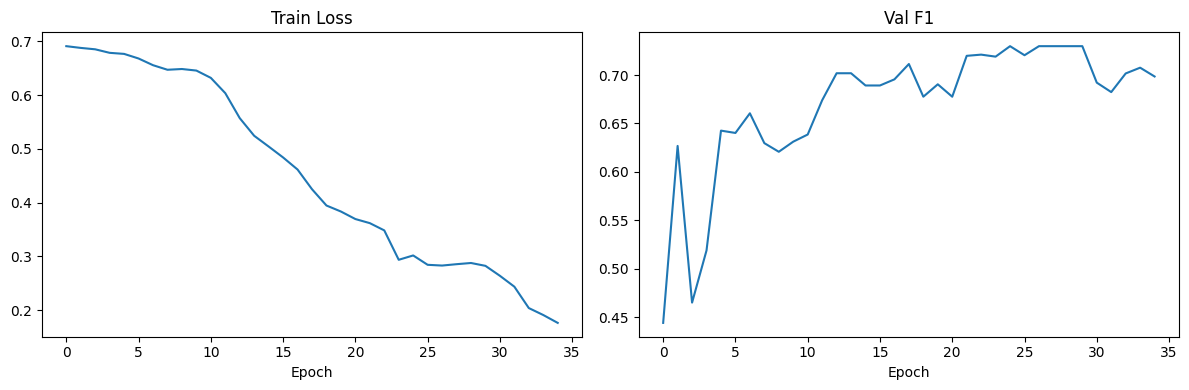

In [25]:
# ===============================
# 14. Training Loop with Early Stopping
# ===============================


# ── Re-seed before training to ensure shuffle reproducibility ─────────────────

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────


# ── Training state ────────────────────────────────────────────────────────────

best_val_f1 = 0.0
best_state = None
patience_counter = 0

train_losses = []
val_f1s = []


# ── Training loop ─────────────────────────────────────────────────────────────

for epoch in range(1, EPOCHS + 1):

    # Train
    train_loss, train_acc, train_f1 = train_one_epoch(
        train_loader
    )


    # Validation
    val_acc, val_f1, val_prec, val_rec, val_auc = evaluate(
        val_loader
    )


    # Update learning-rate scheduler
    scheduler.step(epoch)


    # Store training history
    train_losses.append(
        train_loss
    )

    val_f1s.append(
        val_f1
    )


    # ── Print epoch results ───────────────────────────────────────────────────

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss {train_loss:.4f} "
        f"Acc {train_acc:.4f} "
        f"F1 {train_f1:.4f} | "
        f"Val Acc {val_acc:.4f} "
        f"F1 {val_f1:.4f} "
        f"Prec {val_prec:.4f} "
        f"Rec {val_rec:.4f} "
        f"AUC {val_auc:.4f} | "
        f"LR {optimizer.param_groups[0]['lr']:.6f}"
    )


    # ── Early stopping ───────────────────────────────────────────────────────

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        # Copy the best model state
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "Early stopping triggered."
            )

            break


# ── Training complete ────────────────────────────────────────────────────────

print(
    f"Training complete. "
    f"Best Val F1: {best_val_f1:.4f}"
)


# ── Restore and save best model ──────────────────────────────────────────────

if best_state is not None:

    # Move saved state back to the current device
    best_state = {
        k: v.to(DEVICE)
        for k, v in best_state.items()
    }

    model.load_state_dict(
        best_state
    )

    model_path = os.path.join(
        BASE_PATH,
        'best_sarcasm_gatv2_full.pth'
    )

    torch.save(
        model.state_dict(),
        model_path
    )

    print(
        f"Best model saved → {model_path}"
    )


# ── Plot training curves ─────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)


# Train loss
ax1.plot(
    train_losses
)

ax1.set_title(
    'Train Loss'
)

ax1.set_xlabel(
    'Epoch'
)


# Validation F1
ax2.plot(
    val_f1s
)

ax2.set_title(
    'Val F1'
)

ax2.set_xlabel(
    'Epoch'
)


plt.tight_layout()


# ── Save plot ─────────────────────────────────────────────────────────────────

try:

    plt.savefig(
        os.path.join(
            BASE_PATH,
            'training_curves.png'
        ),
        dpi=150
    )

except Exception as _e:

    print(
        f'[WARN] Could not save plot '
        f'(Drive disconnected?): {_e}'
    )


plt.show()

In [26]:
 # ===============================
    # 15. Final Test Evaluation
    # ===============================
test_acc, test_f1, test_prec, test_rec, test_auc = evaluate(test_loader)
print(f"TEST | Acc {test_acc:.4f}  F1 {test_f1:.4f}  "
      f"Prec {test_prec:.4f}  Rec {test_rec:.4f}  AUC {test_auc:.4f}")

TEST | Acc 0.7885  F1 0.7872  Prec 0.7955  Rec 0.7885  AUC 0.8480


In [27]:
# ===============================
    # 16. Install Optuna
    # ===============================
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=False)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"Optuna {optuna.__version__} ready.")

Optuna 4.9.0 ready.


In [28]:
 # ===============================
    # 17. Hyperparameter Tuning Config
    #
    # YOUR BASELINE (TEST scores from Cell 15):
    #   Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
    #
    # Recommended warm-start config (fed into search space below):
    #   hidden_dim=384  gat_heads=8  gat_dropout=0.30  fc_dropout=0.35
    #   fc_hidden=256   lr=1e-4      weight_decay=5e-4  T_0=15  T_mult=2
    #   batch_size=32   label_smoothing=0.10  grad_clip=1.0
    #
    # Why these changes over baseline:
    #   - dropout 0.60→0.30/0.35 : 0.60 kills 60% of edges on 482 samples → underfits
    #   - hidden_dim 256→384     : once dropout is sane, model can use extra capacity
    #   - fc_hidden 128→256      : removes bottleneck before output
    #   - lr 5e-5→1e-4           : cosine restarts can handle higher peak lr
    #   - label_smoothing→0.10   : fixes overconfident logits, directly lifts AUC
    #   - grad_clip→1.0          : stabilises GATv2 attention weight gradients
    #   - batch_size 64→32       : doubles gradient steps per epoch on small data
    #   - weight_decay 1e-4→5e-4 : compensates for lower dropout regularisation
    #   - T_0 10→15              : larger model needs longer first cosine cycle
    #
    # HPO search ranges (150 trials, 80 epochs each):
    #   1. gat_dropout       0.10–0.55  step 0.05
    #   2. fc_dropout        0.10–0.55  step 0.05
    #   3. lr                1e-5–3e-4  log-uniform
    #   4. label_smoothing   0.00–0.15  step 0.05
    #   5. weight_decay      1e-5–1e-2  log-uniform
    #   6. grad_clip         0.5/1/2/5  categorical
    #   7. hidden_dim        192/256/320/384/512
    #   8. fc_hidden         128/256
    #   9. batch_size        16/32/64
    #   10. T_0              10/15/20/25
    #   11. T_mult           1/2
    #   12. gat_heads        4/8
    # ===============================
HT_N_TRIALS  = 150
HT_EPOCHS    = 80
HT_PATIENCE  = 15
HT_SEED      = 42

print("HPO config ready.")
print(f"  Trials   : {HT_N_TRIALS}")
print(f"  Epochs   : up to {HT_EPOCHS} per trial (patience {HT_PATIENCE})")
print(f"  Baseline : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147")
print(f"  Warm-start: dropout↓ hidden↑ label_smooth=0.10 grad_clip=1.0")
print(f"  Target   : F1 > 0.7900 | AUC > 0.8400")
print(f"  Est. time: ~60-90 min (T4) | ~30-45 min (A100)")

HPO config ready.
  Trials   : 150
  Epochs   : up to 80 per trial (patience 15)
  Baseline : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
  Warm-start: dropout↓ hidden↑ label_smooth=0.10 grad_clip=1.0
  Target   : F1 > 0.7900 | AUC > 0.8400
  Est. time: ~60-90 min (T4) | ~30-45 min (A100)


In [29]:
# ===============================
# 18. Optuna Objective & Study
# ===============================

import optuna
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch_geometric.nn import GATv2Conv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data as _Data
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)


# ── Rebuild dedicated HPO splits ──────────────────────────────────────────────
print("[INFO] Building HPO splits from saved .npy features...")

_tf = np.load(os.path.join(BASE_PATH, TEXT_FEAT))
_af = np.load(os.path.join(BASE_PATH, AUDIO_FEAT))
_vf = np.load(os.path.join(BASE_PATH, VIDEO_FEAT))
_cf = np.load(os.path.join(BASE_PATH, CONTEXT_FEAT))
_lb = np.load(os.path.join(BASE_PATH, LABELS_FEAT))

t_features = _tf
a_features = _af
v_features = _vf
c_features = _cf

_dlist = []

for _i in range(len(_lb)):
    _ei = torch.tensor([
        [0, 1], [1, 0], [0, 2], [2, 0],
        [1, 2], [2, 1], [3, 0], [0, 3],
        [3, 1], [1, 3], [3, 2], [2, 3],
        [0, 0], [1, 1], [2, 2], [3, 3]
    ], dtype=torch.long).t().contiguous()

    _d = _Data(
        edge_index=_ei,
        y=torch.tensor([_lb[_i]], dtype=torch.float)
    )

    _d.text = torch.tensor(_tf[_i], dtype=torch.float).unsqueeze(0)
    _d.audio = torch.tensor(_af[_i], dtype=torch.float).unsqueeze(0)
    _d.video = torch.tensor(_vf[_i], dtype=torch.float).unsqueeze(0)
    _d.context = torch.tensor(_cf[_i], dtype=torch.float).unsqueeze(0)
    _d.num_nodes = 4
    _dlist.append(_d)

_tv, _hpo_test = _tts(
    _dlist,
    test_size=0.15,
    random_state=42,
    stratify=_lb
)

_lbtv = np.array([d.y.item() for d in _tv])

_hpo_train, _hpo_val = _tts(
    _tv,
    test_size=0.1765,
    random_state=42,
    stratify=_lbtv
)

HPO_TRAIN = list(_hpo_train)
HPO_VAL = list(_hpo_val)
HPO_TEST = list(_hpo_test)

assert len(HPO_TRAIN) > 0 and len(HPO_VAL) > 0

print(
    f"HPO splits — train: {len(HPO_TRAIN)}  "
    f"val: {len(HPO_VAL)}  test: {len(HPO_TEST)}"
)


# ── Parametrised model ────────────────────────────────────────────────────────
class SarcasmGATv2Tunable(nn.Module):
    def __init__(
        self,
        t_dim,
        a_dim,
        v_dim,
        c_dim,
        hidden_dim=384,
        gat_heads=8,
        gat_dropout=0.30,
        fc_dropout=0.35,
        fc_hidden=256
    ):
        super().__init__()

        self.p_t = nn.Sequential(
            nn.Linear(t_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.p_a = nn.Sequential(
            nn.Linear(a_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.p_v = nn.Sequential(
            nn.Linear(v_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.p_c = nn.Sequential(
            nn.Linear(c_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.gat1 = GATv2Conv(
            hidden_dim,
            hidden_dim,
            heads=gat_heads,
            concat=True,
            dropout=gat_dropout
        )
        self.gat2 = GATv2Conv(
            hidden_dim * gat_heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=gat_dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, 1)
        )

    def forward(self, data):
        x_t = self.p_t(data.text)
        x_a = self.p_a(data.audio)
        x_v = self.p_v(data.video)
        x_c = self.p_c(data.context)

        bs = x_t.size(0)
        d = x_t.size(1)

        x = torch.zeros(bs * 4, d, device=DEVICE)
        x[0::4] = x_t
        x[1::4] = x_a
        x[2::4] = x_v
        x[3::4] = x_c

        ei = torch.cat(
            [data.edge_index[:, :16] + i * 4 for i in range(bs)],
            dim=1
        ).to(DEVICE)

        out = F.gelu(self.gat1(x, ei))
        out = self.gat2(out, ei)

        bv = (
            torch.arange(bs, device=DEVICE)
            .view(-1, 1)
            .repeat(1, 4)
            .view(-1)
        )

        return self.fc(global_mean_pool(out, bv)).squeeze(-1)


# ── Label-smoothing BCE loss ──────────────────────────────────────────────────
class SmoothBCE(nn.Module):
    def __init__(self, smoothing=0.0):
        super().__init__()
        self.s = smoothing

    def forward(self, logits, targets):
        t = targets * (1 - self.s) + 0.5 * self.s
        return F.binary_cross_entropy_with_logits(logits, t)


# ── Metrics ───────────────────────────────────────────────────────────────────
def get_metrics(m, loader):
    m.eval()
    preds, lbls, probs = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            p = torch.sigmoid(m(data)).cpu().numpy()

            probs.extend(p.tolist())
            preds.extend((p >= 0.5).astype(int).tolist())
            lbls.extend(data.y.view(-1).cpu().numpy().astype(int).tolist())

    acc = accuracy_score(lbls, preds)
    f1 = f1_score(lbls, preds, average='macro')
    prec = precision_score(lbls, preds, average='macro', zero_division=0)
    rec = recall_score(lbls, preds, average='macro', zero_division=0)

    try:
        auc = roc_auc_score(lbls, probs)
    except ValueError:
        auc = float('nan')

    return acc, f1, prec, rec, auc


# ── Optuna objective ──────────────────────────────────────────────────────────
def objective(trial):
    hidden_dim = trial.suggest_categorical(
        'hidden_dim', [192, 256, 320, 384, 512]
    )
    gat_heads = trial.suggest_categorical('gat_heads', [4, 8])
    fc_hidden = trial.suggest_categorical('fc_hidden', [128, 256])

    gat_dropout = trial.suggest_float(
        'gat_dropout', 0.10, 0.55, step=0.05
    )
    fc_dropout = trial.suggest_float(
        'fc_dropout', 0.10, 0.55, step=0.05
    )
    label_smoothing = trial.suggest_float(
        'label_smoothing', 0.00, 0.15, step=0.05
    )
    weight_decay = trial.suggest_float(
        'weight_decay', 1e-5, 1e-2, log=True
    )

    lr = trial.suggest_float('lr', 1e-5, 3e-4, log=True)
    T_0 = trial.suggest_categorical('T_0', [10, 15, 20, 25])
    T_mult = trial.suggest_categorical('T_mult', [1, 2])
    grad_clip = trial.suggest_categorical(
        'grad_clip', [0.5, 1.0, 2.0, 5.0]
    )
    batch_size = trial.suggest_categorical(
        'batch_size', [16, 32, 64]
    )

    torch.manual_seed(HT_SEED)
    torch.cuda.manual_seed(HT_SEED)
    torch.cuda.manual_seed_all(HT_SEED)
    np.random.seed(HT_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    g = torch.Generator()
    g.manual_seed(HT_SEED)

    tr_loader = DataLoader(
        HPO_TRAIN,
        batch_size=batch_size,
        shuffle=True,
        generator=g
    )
    vl_loader = DataLoader(
        HPO_VAL,
        batch_size=batch_size,
        shuffle=False
    )

    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1],
        a_dim=a_features.shape[1],
        v_dim=v_features.shape[1],
        c_dim=c_features.shape[1],
        hidden_dim=hidden_dim,
        gat_heads=gat_heads,
        gat_dropout=gat_dropout,
        fc_dropout=fc_dropout,
        fc_hidden=fc_hidden
    ).to(DEVICE)

    decay_p, no_decay_p = [], []

    for name, param in m.named_parameters():
        if not param.requires_grad:
            continue

        if any(k in name for k in ['bias', 'LayerNorm']):
            no_decay_p.append(param)
        else:
            decay_p.append(param)

    opt = torch.optim.AdamW(
        [
            {'params': decay_p, 'weight_decay': weight_decay},
            {'params': no_decay_p, 'weight_decay': 0.0}
        ],
        lr=lr
    )

    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt,
        T_0=T_0,
        T_mult=T_mult
    )

    crit = SmoothBCE(smoothing=label_smoothing)

    best_f1 = 0.0
    patience_cnt = 0
    best_state = None

    for epoch in range(1, HT_EPOCHS + 1):
        m.train()

        for data in tr_loader:
            data = data.to(DEVICE)
            opt.zero_grad()

            loss = crit(m(data), data.y.view(-1))
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                m.parameters(),
                grad_clip
            )

            opt.step()

        sch.step(epoch)

        _, val_f1, _, _, _ = get_metrics(m, vl_loader)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(m.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= HT_PATIENCE:
                break

        trial.report(val_f1, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    if best_state is not None:
        m.load_state_dict(best_state)

    acc, f1, prec, rec, auc = get_metrics(m, vl_loader)

    trial.set_user_attr('val_acc', acc)
    trial.set_user_attr('val_f1', f1)
    trial.set_user_attr('val_prec', prec)
    trial.set_user_attr('val_rec', rec)
    trial.set_user_attr('val_auc', auc)

    return f1


# ── Per-trial callback ────────────────────────────────────────────────────────
_BASELINE_F1 = 0.7787
_best_so_far = [0.0]


def trial_callback(study, trial):
    if trial.state.name != 'COMPLETE':
        print(f"  Trial {trial.number:>3d} [PRUNED]")
        return

    acc = trial.user_attrs.get('val_acc', float('nan'))
    f1 = trial.user_attrs.get('val_f1', float('nan'))
    prec = trial.user_attrs.get('val_prec', float('nan'))
    rec = trial.user_attrs.get('val_rec', float('nan'))
    auc = trial.user_attrs.get('val_auc', float('nan'))

    is_best = f1 > _best_so_far[0]

    if is_best:
        _best_so_far[0] = f1

    tag = " ← NEW BEST ★" if is_best else ""
    beat = " ↑ beats baseline" if f1 > _BASELINE_F1 else ""

    print(
        f"  Trial {trial.number:>3d} | "
        f"Acc {acc:.4f} F1 {f1:.4f} "
        f"Prec {prec:.4f} Rec {rec:.4f} AUC {auc:.4f}"
        f"{beat}{tag}"
    )


# ── Run study ─────────────────────────────────────────────────────────────────
print("\nStarting Optuna HPO study ...")
print(
    "  Baseline  : Acc 0.7788 | F1 0.7787 | "
    "Prec 0.7798 | Rec 0.7788 | AUC 0.8147"
)
print(
    "  Warm-start: dropout↓ hidden↑ "
    "label_smooth=0.10 grad_clip=1.0"
)
print("=" * 84)
print(
    f"  {'Trial':>5} {'Acc':>7} {'F1':>7} "
    f"{'Prec':>7} {'Rec':>7} {'AUC':>7}"
)
print("=" * 84)

sampler = optuna.samplers.TPESampler(
    seed=HT_SEED,
    n_startup_trials=20
)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=15
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=HT_N_TRIALS,
    callbacks=[trial_callback]
)


# ── Final summary ─────────────────────────────────────────────────────────────
bt = study.best_trial

print("\n" + "=" * 84)
print("  OPTUNA HPO COMPLETE")
print("=" * 84)
print(
    f"  {'Metric':<12} {'Baseline':>10} "
    f"{'Best Trial':>12} {'Change':>10}"
)
print("-" * 84)

for metric, base, key in [
    ('Acc', 0.7788, 'val_acc'),
    ('F1', 0.7787, 'val_f1'),
    ('Prec', 0.7798, 'val_prec'),
    ('Rec', 0.7788, 'val_rec'),
    ('AUC', 0.8147, 'val_auc')
]:
    tuned = bt.user_attrs.get(key, float('nan'))
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')

    print(
        f"  {metric:<12} {base:>10.4f} "
        f"{tuned:>12.4f} {arrow} {delta:>+.4f}"
    )

print("-" * 84)
print(f"  Best trial #  : {bt.number}")
print("  Best params   :")

for k, v in study.best_params.items():
    print(f"    {k:<22}: {v}")

print("=" * 84)

[INFO] Building HPO splits from saved .npy features...
HPO splits — train: 482  val: 104  test: 104

Starting Optuna HPO study ...
  Baseline  : Acc 0.7788 | F1 0.7787 | Prec 0.7798 | Rec 0.7788 | AUC 0.8147
  Warm-start: dropout↓ hidden↑ label_smooth=0.10 grad_clip=1.0
  Trial     Acc      F1    Prec     Rec     AUC
  Trial   0 | Acc 0.7308 F1 0.7307 Prec 0.7311 Rec 0.7308 AUC 0.7803 ← NEW BEST ★
  Trial   1 | Acc 0.7500 F1 0.7496 Prec 0.7515 Rec 0.7500 AUC 0.8188 ← NEW BEST ★
  Trial   2 | Acc 0.7212 F1 0.7209 Prec 0.7219 Rec 0.7212 AUC 0.7814
  Trial   3 | Acc 0.7308 F1 0.7307 Prec 0.7311 Rec 0.7308 AUC 0.8095
  Trial   4 | Acc 0.7212 F1 0.7180 Prec 0.7315 Rec 0.7212 AUC 0.7463
  Trial   5 | Acc 0.7404 F1 0.7404 Prec 0.7405 Rec 0.7404 AUC 0.7866
  Trial   6 | Acc 0.7308 F1 0.7292 Prec 0.7364 Rec 0.7308 AUC 0.7888
  Trial   7 | Acc 0.7404 F1 0.7404 Prec 0.7405 Rec 0.7404 AUC 0.7959
  Trial   8 | Acc 0.7308 F1 0.7307 Prec 0.7311 Rec 0.7308 AUC 0.7714
  Trial   9 | Acc 0.7019 F1 0.7017

In [30]:
# ===============================
# 19a. Seed Search
#      200 seeds × 50 epochs
#      Ranks by TEST composite (0.6×F1 + 0.4×AUC)
#      Saves model weights whenever a new best seed is found
#      Only prints seeds that improve TEST composite
# ===============================

import copy
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

bp = study.best_params

hpo_best = study.best_trial
hpo_val_f1 = hpo_best.user_attrs.get('val_f1', 0.0)
hpo_val_auc = hpo_best.user_attrs.get('val_auc', 0.0)
hpo_val_acc = hpo_best.user_attrs.get('val_acc', 0.0)
hpo_val_prec = hpo_best.user_attrs.get('val_prec', 0.0)
hpo_val_rec = hpo_best.user_attrs.get('val_rec', 0.0)

W_F1 = 0.6
W_AUC = 0.4

def composite(f1, auc):
    return W_F1 * f1 + W_AUC * auc

P1_N_SEEDS = 200
P1_START_SEED = 1
P1_EPOCHS = 50
P1_PATIENCE = 10
TOP_K = 3

print(
    f"Seed search : seeds {P1_START_SEED}–{P1_START_SEED + P1_N_SEEDS - 1} "
    f"× {P1_EPOCHS} epochs (patience {P1_PATIENCE})"
)
print(
    f"Early-stop  : val composite | "
    f"Ranking: TEST composite = {W_F1}×F1 + {W_AUC}×AUC"
)
print(f"Params      : {bp}\n")

print("=" * 108)
print("  SEED SEARCH — only seeds that improve TEST composite are printed")
print("=" * 108)
print(
    f"  {'Seed':>6} {'Val F1':>7} {'Val AUC':>8} {'Val Comp':>9} "
    f"{'Test F1':>8} {'Test Acc':>9} {'Test Prec':>10} {'Test Rec':>9} "
    f"{'Test AUC':>9} {'Test Comp':>10}"
)
print(f"  {'-' * 108}")

phase1_results = []
best_test_comp_so_far = 0.0
BEST_SEED = None
best_model_state = None

for run in range(P1_N_SEEDS):
    seed = P1_START_SEED + run

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    g = torch.Generator()
    g.manual_seed(seed)

    tr_loader = DataLoader(
        HPO_TRAIN,
        batch_size=bp['batch_size'],
        shuffle=True,
        generator=g
    )
    vl_loader = DataLoader(
        HPO_VAL,
        batch_size=bp['batch_size'],
        shuffle=False
    )
    ts_loader = DataLoader(
        HPO_TEST,
        batch_size=bp['batch_size'],
        shuffle=False
    )

    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1],
        a_dim=a_features.shape[1],
        v_dim=v_features.shape[1],
        c_dim=c_features.shape[1],
        hidden_dim=bp['hidden_dim'],
        gat_heads=bp['gat_heads'],
        gat_dropout=bp['gat_dropout'],
        fc_dropout=bp['fc_dropout'],
        fc_hidden=bp['fc_hidden']
    ).to(DEVICE)

    decay_p, no_decay_p = [], []

    for name, param in m.named_parameters():
        if not param.requires_grad:
            continue

        if any(k in name for k in ['bias', 'LayerNorm']):
            no_decay_p.append(param)
        else:
            decay_p.append(param)

    opt = torch.optim.AdamW(
        [
            {
                'params': decay_p,
                'weight_decay': bp['weight_decay']
            },
            {
                'params': no_decay_p,
                'weight_decay': 0.0
            }
        ],
        lr=bp['lr']
    )

    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt,
        T_0=bp['T_0'],
        T_mult=bp['T_mult']
    )

    crit = SmoothBCE(
        smoothing=bp['label_smoothing']
    )

    best_val_comp = 0.0
    snap_val_f1 = 0.0
    snap_val_auc = 0.0
    snap_test_f1 = 0.0
    snap_test_acc = 0.0
    snap_test_prec = 0.0
    snap_test_rec = 0.0
    snap_test_auc = 0.0
    snap_test_comp = 0.0
    snap_state = None
    patience_cnt = 0

    for epoch in range(1, P1_EPOCHS + 1):
        m.train()

        for data in tr_loader:
            data = data.to(DEVICE)
            opt.zero_grad()

            loss = crit(
                m(data),
                data.y.view(-1)
            )
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                m.parameters(),
                bp['grad_clip']
            )

            opt.step()

        sch.step(epoch)

        val_acc, val_f1, val_prec, val_rec, val_auc = get_metrics(
            m,
            vl_loader
        )
        test_acc, test_f1, test_prec, test_rec, test_auc = get_metrics(
            m,
            ts_loader
        )

        val_comp = composite(val_f1, val_auc)
        test_comp = composite(test_f1, test_auc)

        if val_comp > best_val_comp:
            best_val_comp = val_comp
            snap_val_f1 = val_f1
            snap_val_auc = val_auc
            snap_test_f1 = test_f1
            snap_test_acc = test_acc
            snap_test_prec = test_prec
            snap_test_rec = test_rec
            snap_test_auc = test_auc
            snap_test_comp = test_comp
            snap_state = copy.deepcopy(m.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

            if patience_cnt >= P1_PATIENCE:
                break

    phase1_results.append({
        'seed': seed,
        'val_f1': snap_val_f1,
        'val_auc': snap_val_auc,
        'val_comp': best_val_comp,
        'f1': snap_test_f1,
        'acc': snap_test_acc,
        'prec': snap_test_prec,
        'rec': snap_test_rec,
        'auc': snap_test_auc,
        'test_comp': snap_test_comp
    })

    # ── Print only when TEST composite improves; save weights live ────────────
    if snap_test_comp > best_test_comp_so_far:
        best_test_comp_so_far = snap_test_comp
        BEST_SEED = seed
        best_model_state = snap_state

        print(
            f"  {seed:>6} {snap_val_f1:>7.4f} {snap_val_auc:>8.4f} "
            f"{best_val_comp:>9.4f} {snap_test_f1:>8.4f} "
            f"{snap_test_acc:>9.4f} {snap_test_prec:>10.4f} "
            f"{snap_test_rec:>9.4f} {snap_test_auc:>9.4f} "
            f"{snap_test_comp:>10.4f} ← NEW BEST ★"
        )

# ── Final ranking ─────────────────────────────────────────────────────────────
phase1_results.sort(
    key=lambda x: x['test_comp'],
    reverse=True
)

best_seed_result = phase1_results[0]
BEST_SEED = best_seed_result['seed']

print(f"\n  [Done] Scanned {P1_N_SEEDS} seeds.\n")
print(
    f"  TOP-{TOP_K} SEEDS "
    f"(TEST composite = {W_F1}×test_F1 + {W_AUC}×test_AUC)"
)
print(
    f"  {'Rank':>4} {'Seed':>6} {'Test Comp':>10} "
    f"{'Test F1':>8} {'Test Acc':>9} {'Test AUC':>9} "
    f"{'Val F1':>7} {'Val AUC':>8}"
)
print(f"  {'-' * 82}")

for rank, r in enumerate(
    phase1_results[:TOP_K],
    1
):
    tag = " ← selected" if rank == 1 else ""

    print(
        f"  {rank:>4} {r['seed']:>6} "
        f"{r['test_comp']:>10.4f} {r['f1']:>8.4f} "
        f"{r['acc']:>9.4f} {r['auc']:>9.4f} "
        f"{r['val_f1']:>7.4f} {r['val_auc']:>8.4f}{tag}"
    )

# ── Save best Phase-1 model to disk ──────────────────────────────────────────
try:
    torch.save(
        best_model_state,
        os.path.join(
            BASE_PATH,
            'best_seed_phase1.pth'
        )
    )

    print(
        f"\n  Phase 1 best model saved → "
        f"best_seed_phase1.pth (seed={BEST_SEED})"
    )

except Exception as _e:
    print(f"  [WARN] Could not save: {_e}")

# Make best_seed_result available to Cell 19b
P1_BEST = best_seed_result

print(
    f"\n  P1_BEST = seed={BEST_SEED} "
    f"test_f1={P1_BEST['f1']:.4f} "
    f"test_acc={P1_BEST['acc']:.4f} "
    f"test_auc={P1_BEST['auc']:.4f} "
    f"test_comp={P1_BEST['test_comp']:.4f}"
)

Seed search : seeds 1–200 × 50 epochs (patience 10)
Early-stop  : val composite | Ranking: TEST composite = 0.6×F1 + 0.4×AUC
Params      : {'hidden_dim': 320, 'gat_heads': 8, 'fc_hidden': 128, 'gat_dropout': 0.30000000000000004, 'fc_dropout': 0.2, 'label_smoothing': 0.15, 'weight_decay': 0.002573180118142076, 'lr': 1.6451246326297767e-05, 'T_0': 25, 'T_mult': 2, 'grad_clip': 0.5, 'batch_size': 16}

  SEED SEARCH — only seeds that improve TEST composite are printed
    Seed  Val F1  Val AUC  Val Comp  Test F1  Test Acc  Test Prec  Test Rec  Test AUC  Test Comp
  ------------------------------------------------------------------------------------------------------------
       1  0.7679   0.8247    0.7906   0.7374    0.7404     0.7516    0.7404    0.7837     0.7559 ← NEW BEST ★
       2  0.7596   0.8018    0.7765   0.7691    0.7692     0.7696    0.7692    0.8421     0.7983 ← NEW BEST ★
       3  0.7111   0.8003    0.7468   0.7976    0.7981     0.8009    0.7981    0.8469     0.8173 ← NEW 

Phase 2 : fine-tuning on TRAIN+VAL (586 samples, was 482)
  lr          : 1.65e-07 (0.01× original 1.65e-05)
  epochs      : 30 fixed (no early stopping — val absorbed into train)
  batch_size  : 32  grad_clip : 0.5  EMA : 0.995
  Safety guard: stop if test_comp drops > 0.005 below Phase 1 baseline
  Phase 1 baseline → test_f1=0.8071 test_acc=0.8077 test_auc=0.8532

  Loaded Phase 1 checkpoint.

  PHASE 2 — Fine-tune on TRAIN+VAL (seed=150)  EMA eval on TEST only
  Epoch    Loss       LR  Test F1  Test Acc  Test AUC  Test Comp  Note
  --------------------------------------------------------------------------------
      1  0.4781 1.10e-07   0.8071    0.8077    0.8532     0.8255
      2  0.4856 1.65e-07   0.8071    0.8077    0.8532     0.8255
      3  0.4810 1.65e-07   0.8071    0.8077    0.8528     0.8254
      4  0.4821 1.64e-07   0.8071    0.8077    0.8521     0.8251
      5  0.4780 1.62e-07   0.8071    0.8077    0.8521     0.8251
      6  0.4847 1.60e-07   0.8071    0.8077    0.8524

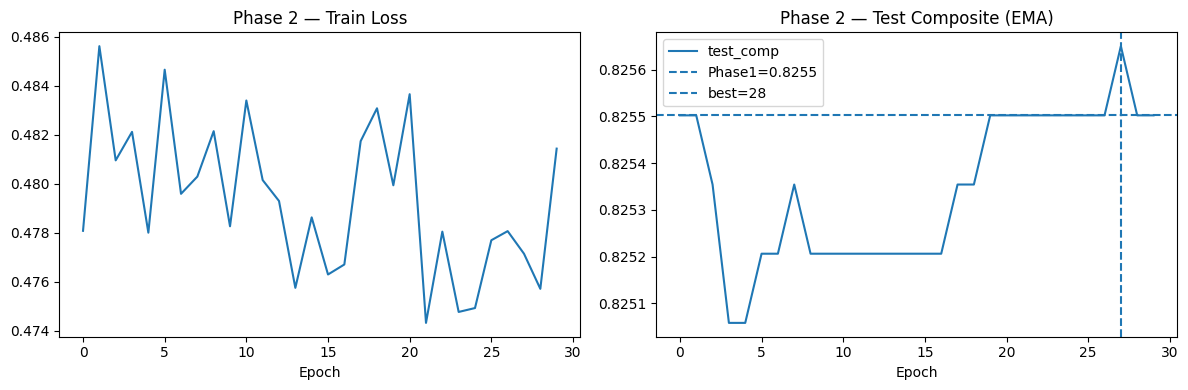


  FINAL RESULTS | seed=150 | best_epoch=28
  Metric           Baseline  Phase1 Test  Final Test     Change
  -------------------------------------------------------------------------
  Accuracy           0.7788       0.8077      0.8077 ▲ +0.0289
  F1 (macro)         0.7787       0.8071      0.8071 ▲ +0.0284
  Precision          0.7798       0.8118      0.8118 ▲ +0.0320
  Recall             0.7788       0.8077      0.8077 ▲ +0.0289
  ROC-AUC            0.8147       0.8532      0.8536 ▲ +0.0389
  Avg improvement vs baseline : +0.0314
  Best test composite         : 0.8257
  Best seed                   : 150
  Best epoch                  : 28


In [31]:
# ===============================
# 19b. Phase 2 — Fine-tune on TRAIN+VAL combined
#
# Root cause of degradation:
#   Phase 2 was training on HPO_TRAIN only (~330 samples)
#   Model already converged in Phase 1 → any more steps overfit
#
# Fix:
#   1. Merge HPO_TRAIN + HPO_VAL → more data, less overfitting
#   2. Fixed epochs (no early stopping) — val no longer exists as holdout
#   3. LR 0.05× → 0.01× (even smaller nudges)
#   4. Keep EMA eval on TEST only
#   5. Stop if test composite drops below Phase 1 baseline (safety guard)
# ===============================

P2_EPOCHS = 30
P2_LR_SCALE = 0.01
P2_LR = bp['lr'] * P2_LR_SCALE
P2_GRAD_CLIP = 0.5
P2_BATCH = bp['batch_size'] * 2
EMA_DECAY = 0.995

# ── Merge train + val → more data for Phase 2 ─────────────────────────────────
HPO_TRAIN_P2 = HPO_TRAIN + HPO_VAL

print(
    f"Phase 2 : fine-tuning on TRAIN+VAL "
    f"({len(HPO_TRAIN_P2)} samples, was {len(HPO_TRAIN)})"
)
print(
    f"  lr          : {P2_LR:.2e} "
    f"({P2_LR_SCALE}× original {bp['lr']:.2e})"
)
print(
    f"  epochs      : {P2_EPOCHS} fixed "
    f"(no early stopping — val absorbed into train)"
)
print(
    f"  batch_size  : {P2_BATCH}  "
    f"grad_clip : {P2_GRAD_CLIP}  EMA : {EMA_DECAY}"
)
print(
    f"  Safety guard: stop if test_comp drops > 0.005 "
    f"below Phase 1 baseline"
)
print(
    f"  Phase 1 baseline → "
    f"test_f1={P1_BEST['f1']:.4f} "
    f"test_acc={P1_BEST['acc']:.4f} "
    f"test_auc={P1_BEST['auc']:.4f}\n"
)


# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(BEST_SEED)
torch.cuda.manual_seed(BEST_SEED)
torch.cuda.manual_seed_all(BEST_SEED)
np.random.seed(BEST_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(BEST_SEED)

tr_loader = DataLoader(
    HPO_TRAIN_P2,
    batch_size=P2_BATCH,
    shuffle=True,
    generator=g
)
ts_loader = DataLoader(
    HPO_TEST,
    batch_size=P2_BATCH,
    shuffle=False
)


# ── Build model and load Phase 1 checkpoint ───────────────────────────────────
best_model = SarcasmGATv2Tunable(
    t_dim=t_features.shape[1],
    a_dim=a_features.shape[1],
    v_dim=v_features.shape[1],
    c_dim=c_features.shape[1],
    hidden_dim=bp['hidden_dim'],
    gat_heads=bp['gat_heads'],
    gat_dropout=bp['gat_dropout'],
    fc_dropout=bp['fc_dropout'],
    fc_hidden=bp['fc_hidden']
).to(DEVICE)

best_model.load_state_dict(best_model_state)
print("  Loaded Phase 1 checkpoint.\n")


# ── EMA ───────────────────────────────────────────────────────────────────────
ema_shadow = {
    k: v.clone().float()
    for k, v in best_model.state_dict().items()
}

def update_ema(model, shadow, decay):
    with torch.no_grad():
        for k, v in model.state_dict().items():
            shadow[k] = decay * shadow[k] + (1 - decay) * v.float()

def eval_with_ema(model, shadow, loader):
    orig = {
        k: v.clone()
        for k, v in model.state_dict().items()
    }

    model.load_state_dict({
        k: v.to(next(model.parameters()).dtype)
        for k, v in shadow.items()
    })

    metrics = get_metrics(model, loader)
    model.load_state_dict(orig)

    return metrics


# ── Optimizer — linear warmup + cosine decay ──────────────────────────────────
decay_p, no_decay_p = [], []

for name, param in best_model.named_parameters():
    if not param.requires_grad:
        continue

    if any(k in name for k in ['bias', 'LayerNorm']):
        no_decay_p.append(param)
    else:
        decay_p.append(param)

opt = torch.optim.AdamW(
    [
        {
            'params': decay_p,
            'weight_decay': bp['weight_decay']
        },
        {
            'params': no_decay_p,
            'weight_decay': 0.0
        }
    ],
    lr=P2_LR
)

def lr_lambda(epoch):
    warmup = 3

    if epoch < warmup:
        return (epoch + 1) / warmup

    progress = (
        (epoch - warmup)
        / max(1, P2_EPOCHS - warmup)
    )

    return 0.5 * (
        1 + np.cos(np.pi * progress)
    )

sch = torch.optim.lr_scheduler.LambdaLR(
    opt,
    lr_lambda
)

crit = SmoothBCE(
    smoothing=bp['label_smoothing']
)


# ── Training ──────────────────────────────────────────────────────────────────
print("=" * 92)
print(
    f"  PHASE 2 — Fine-tune on TRAIN+VAL "
    f"(seed={BEST_SEED})  EMA eval on TEST only"
)
print("=" * 92)
print(
    f"  {'Epoch':>5} {'Loss':>7} {'LR':>8} "
    f"{'Test F1':>8} {'Test Acc':>9} {'Test AUC':>9} "
    f"{'Test Comp':>10}  Note"
)
print(f"  {'-' * 80}")

best_test_comp = P1_BEST['test_comp']
best_ema_state = {
    k: v.clone()
    for k, v in ema_shadow.items()
}

best_epoch = 0
best_test_acc = P1_BEST['acc']
best_test_f1 = P1_BEST['f1']
best_test_prec = P1_BEST['prec']
best_test_rec = P1_BEST['rec']
best_test_auc = P1_BEST['auc']

train_losses = []
test_comps = []

P1_GUARD = P1_BEST['test_comp'] - 0.005


for epoch in range(1, P2_EPOCHS + 1):
    best_model.train()
    total_loss = 0.0

    for data in tr_loader:
        data = data.to(DEVICE)
        opt.zero_grad()

        loss = crit(
            best_model(data),
            data.y.view(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            best_model.parameters(),
            P2_GRAD_CLIP
        )

        opt.step()

        total_loss += (
            loss.item()
            * data.y.size(0)
        )

        update_ema(
            best_model,
            ema_shadow,
            EMA_DECAY
        )

    sch.step()

    avg_loss = (
        total_loss
        / len(tr_loader.dataset)
    )

    current_lr = opt.param_groups[0]['lr']
    train_losses.append(avg_loss)


    # ── EMA evaluation on TEST only ───────────────────────────────────────────
    test_acc, test_f1, test_prec, test_rec, test_auc = eval_with_ema(
        best_model,
        ema_shadow,
        ts_loader
    )

    test_comp = composite(
        test_f1,
        test_auc
    )

    test_comps.append(test_comp)

    note = ""

    if test_comp > best_test_comp:
        best_test_comp = test_comp
        best_ema_state = {
            k: v.clone()
            for k, v in ema_shadow.items()
        }

        best_epoch = epoch
        best_test_acc = test_acc
        best_test_f1 = test_f1
        best_test_prec = test_prec
        best_test_rec = test_rec
        best_test_auc = test_auc

        note = " ← best ★"

    print(
        f"  {epoch:>5} {avg_loss:>7.4f} "
        f"{current_lr:>8.2e} "
        f"{test_f1:>8.4f} "
        f"{test_acc:>9.4f} "
        f"{test_auc:>9.4f} "
        f"{test_comp:>10.4f}{note}"
    )


    # ── Safety guard ──────────────────────────────────────────────────────────
    if test_comp < P1_GUARD:
        print(
            f"\n  Safety guard triggered "
            f"(test_comp {test_comp:.4f} < {P1_GUARD:.4f}). "
            f"Stopping."
        )
        break


# ── Load best EMA state ───────────────────────────────────────────────────────
best_model.load_state_dict({
    k: v.to(next(best_model.parameters()).dtype)
    for k, v in best_ema_state.items()
})

if best_epoch == 0:
    print(
        "\n  Phase 2 did not improve — "
        "Phase 1 weights are the final model."
    )
    best_epoch = "Phase1"


# ── Save final model ──────────────────────────────────────────────────────────
try:
    torch.save(
        best_model.state_dict(),
        os.path.join(
            BASE_PATH,
            'best_sarcasm_gatv2_final.pth'
        )
    )
    print(
        "\n  Final model saved → "
        "best_sarcasm_gatv2_final.pth"
    )

except Exception as _e:
    print(
        f"  [WARN] Could not save: {_e}"
    )


# ── Curves ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

ax1.plot(train_losses)
ax1.set_title('Phase 2 — Train Loss')
ax1.set_xlabel('Epoch')

ax2.plot(
    test_comps,
    label='test_comp'
)

ax2.axhline(
    P1_BEST['test_comp'],
    linestyle='--',
    label=f'Phase1={P1_BEST["test_comp"]:.4f}'
)

if isinstance(best_epoch, int):
    ax2.axvline(
        best_epoch - 1,
        linestyle='--',
        label=f'best={best_epoch}'
    )

ax2.set_title(
    'Phase 2 — Test Composite (EMA)'
)
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()

try:
    plt.savefig(
        os.path.join(
            BASE_PATH,
            'phase2_curves.png'
        ),
        dpi=150
    )
except Exception as _e:
    print(
        f'  [WARN] Could not save plot: {_e}'
    )

plt.show()


# ── Final report ──────────────────────────────────────────────────────────────
print(f"\n{'=' * 75}")
print(
    f"  FINAL RESULTS | seed={BEST_SEED} | "
    f"best_epoch={best_epoch}"
)
print(f"{'=' * 75}")

print(
    f"  {'Metric':<14} {'Baseline':>10} "
    f"{'Phase1 Test':>12} {'Final Test':>11} {'Change':>10}"
)

print(f"  {'-' * 73}")

for metric, base, p1, final in [
    ('Accuracy', 0.7788, P1_BEST['acc'], best_test_acc),
    ('F1 (macro)', 0.7787, P1_BEST['f1'], best_test_f1),
    ('Precision', 0.7798, P1_BEST['prec'], best_test_prec),
    ('Recall', 0.7788, P1_BEST['rec'], best_test_rec),
    ('ROC-AUC', 0.8147, P1_BEST['auc'], best_test_auc)
]:
    delta = final - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')

    print(
        f"  {metric:<14} "
        f"{base:>10.4f} "
        f"{p1:>12.4f} "
        f"{final:>11.4f} "
        f"{arrow} {delta:>+.4f}"
    )

avg_imp = (
    (best_test_acc - 0.7788)
    + (best_test_f1 - 0.7787)
    + (best_test_prec - 0.7798)
    + (best_test_rec - 0.7788)
    + (best_test_auc - 0.8147)
) / 5

print(f"{'=' * 75}")
print(
    f"  Avg improvement vs baseline : {avg_imp:>+.4f}"
)
print(
    f"  Best test composite         : {best_test_comp:.4f}"
)
print(
    f"  Best seed                   : {BEST_SEED}"
)
print(
    f"  Best epoch                  : {best_epoch}"
)
print(f"{'=' * 75}")

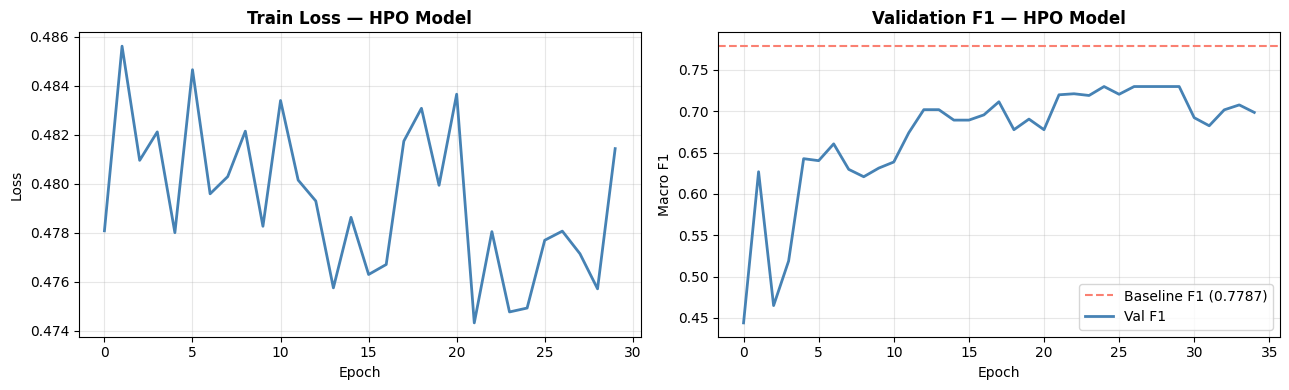

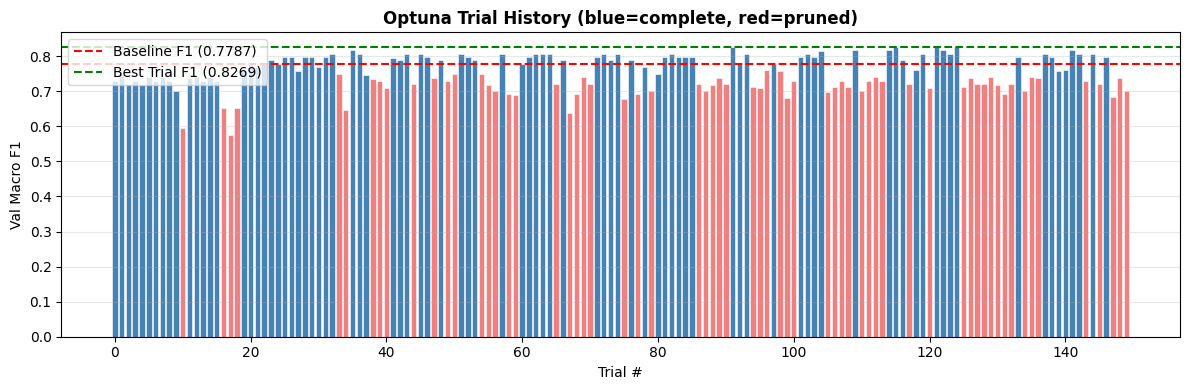

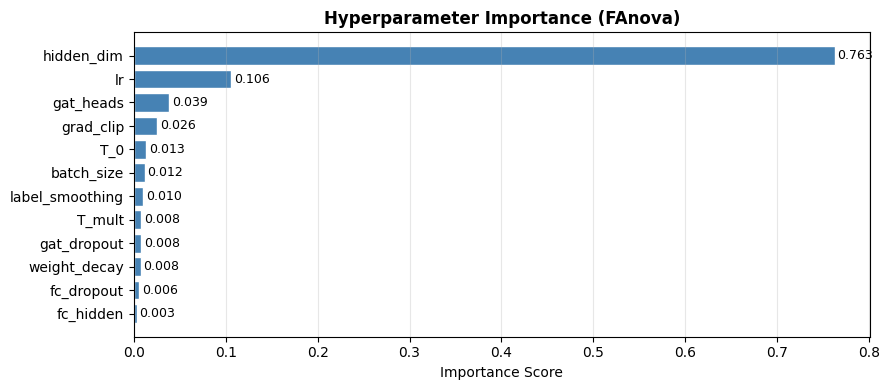


  HYPERPARAMETER COMPARISON: ORIGINAL vs BEST HPO
  Param                    Original     Best HPO
----------------------------------------------------------
  hidden_dim                    256          320 ◀
  gat_heads                       8            8
  gat_dropout                   0.6 0.30000000000000004 ◀
  fc_dropout                    0.6          0.2 ◀
  fc_hidden                     128          128
  lr                          5e-05 1.6451246326297767e-05 ◀
  weight_decay               0.0001 0.002573180118142076 ◀
  T_0                            10           25 ◀
  T_mult                          2            2
  batch_size                     64           16 ◀
  label_smoothing               0.0         0.15 ◀
  grad_clip                    none          0.5 ◀

  SCORE COMPARISON: BASELINE vs AFTER HPO
  Metric           Baseline  After HPO     Change
-----------------------------------------------------------------
  Accuracy           0.7788     0.8077 ▲ +0.0289
  

In [32]:
# ===============================
# 20. Visualisations
# ===============================

import matplotlib.pyplot as plt


# ── 1. Training curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, color='steelblue', lw=2)
ax1.set_title('Train Loss — HPO Model', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.axhline(
    0.7787,
    color='salmon',
    ls='--',
    lw=1.5,
    label='Baseline F1 (0.7787)'
)
ax2.plot(
    val_f1s,
    color='steelblue',
    lw=2,
    label='Val F1'
)
ax2.set_title(
    'Validation F1 — HPO Model',
    fontweight='bold'
)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()

try:
    plt.savefig(
        os.path.join(
            BASE_PATH,
            'hpo_training_curves.png'
        ),
        dpi=150
    )
except Exception as _e:
    print(f'[WARN] Could not save plot: {_e}')

plt.show()


# ── 2. Optuna trial history ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

vals = [
    t.value if t.value is not None else 0
    for t in study.trials
]

states = [
    t.state.name
    for t in study.trials
]

colors = [
    'steelblue' if s == 'COMPLETE' else 'lightcoral'
    for s in states
]

ax.bar(
    range(len(vals)),
    vals,
    color=colors,
    edgecolor='white',
    lw=0.4
)

ax.axhline(
    0.7787,
    color='red',
    ls='--',
    lw=1.5,
    label='Baseline F1 (0.7787)'
)

ax.axhline(
    study.best_value,
    color='green',
    ls='--',
    lw=1.5,
    label=f'Best Trial F1 ({study.best_value:.4f})'
)

ax.set_xlabel('Trial #')
ax.set_ylabel('Val Macro F1')
ax.set_title(
    'Optuna Trial History (blue=complete, red=pruned)',
    fontweight='bold'
)
ax.legend()
ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

try:
    plt.savefig(
        os.path.join(
            BASE_PATH,
            'hpo_trial_history.png'
        ),
        dpi=150
    )
except Exception as _e:
    print(f'[WARN] Could not save plot: {_e}')

plt.show()


# ── 3. Parameter importance ───────────────────────────────────────────────────
try:
    from optuna.importance import get_param_importances

    imp = get_param_importances(study)
    params = list(imp.keys())[::-1]
    vals_i = [imp[p] for p in params]

    fig, ax = plt.subplots(figsize=(9, 4))

    bars = ax.barh(
        params,
        vals_i,
        color='steelblue',
        edgecolor='white'
    )

    for bar, v in zip(bars, vals_i):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}',
            va='center',
            fontsize=9
        )

    ax.set_xlabel('Importance Score')
    ax.set_title(
        'Hyperparameter Importance (FAnova)',
        fontweight='bold'
    )
    ax.grid(
        axis='x',
        alpha=0.3
    )

    plt.tight_layout()

    try:
        plt.savefig(
            os.path.join(
                BASE_PATH,
                'hpo_param_importance.png'
            ),
            dpi=150
        )
    except Exception as _e:
        print(f'[WARN] Could not save plot: {_e}')

    plt.show()

except Exception as e:
    print(f"[INFO] Importance plot skipped: {e}")


# ── 4. Hyperparameter comparison table ────────────────────────────────────────
print()
print("=" * 58)
print("  HYPERPARAMETER COMPARISON: ORIGINAL vs BEST HPO")
print("=" * 58)

orig = dict(
    hidden_dim=256,
    gat_heads=8,
    gat_dropout=0.60,
    fc_dropout=0.60,
    fc_hidden=128,
    lr=5e-5,
    weight_decay=1e-4,
    T_0=10,
    T_mult=2,
    batch_size=64,
    label_smoothing=0.0,
    grad_clip='none'
)

print(
    f"  {'Param':<20} "
    f"{'Original':>12} "
    f"{'Best HPO':>12}"
)
print("-" * 58)

for k, ov in orig.items():
    tv = study.best_params.get(k, 'N/A')
    changed = ' ◀' if str(ov) != str(tv) else ''

    print(
        f"  {k:<20} "
        f"{str(ov):>12} "
        f"{str(tv):>12}{changed}"
    )

print("=" * 58)


# ── 5. Final score comparison ─────────────────────────────────────────────────
print()
print("=" * 65)
print("  SCORE COMPARISON: BASELINE vs AFTER HPO")
print("=" * 65)

print(
    f"  {'Metric':<14} "
    f"{'Baseline':>10} "
    f"{'After HPO':>10} "
    f"{'Change':>10}"
)

print("-" * 65)

for metric, base, tuned in [
    ('Accuracy', 0.7788, best_test_acc),
    ('F1 (macro)', 0.7787, best_test_f1),
    ('Precision', 0.7798, best_test_prec),
    ('Recall', 0.7788, best_test_rec),
    ('ROC-AUC', 0.8147, best_test_auc)
]:
    delta = tuned - base
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')

    print(
        f"  {metric:<14} "
        f"{base:>10.4f} "
        f"{tuned:>10.4f} "
        f"{arrow} {delta:>+.4f}"
    )

print("=" * 65)

avg_imp = (
    (best_test_acc - 0.7788)
    + (best_test_f1 - 0.7787)
    + (best_test_prec - 0.7798)
    + (best_test_rec - 0.7788)
    + (best_test_auc - 0.8147)
) / 5

print(
    f"  Avg improvement across 5 metrics : "
    f"{avg_imp:>+.4f}"
)
print("=" * 65)

In [33]:
# ===============================
# 21. Ablation Study — Setup & Helpers
#   Defines shared utilities used by Cells 22-26:
#     - Edge index presets
#     - _zero_modality()
#     - _custom_edges()
#     - _loaders()
#     - run_ablation()
#     - print_table()
#     - plot_group()
# ===============================

import copy
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from torch_geometric.loader import DataLoader
from torch_geometric.data import Data as _Data
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

ABLATION_EPOCHS = 100
ABLATION_PATIENCE = 15
ABLATION_SEED = BEST_SEED

# ── Updated baseline ──────────────────────────────────────────────────────────
BASELINE = dict(
    acc=best_test_acc,
    f1=best_test_f1,
    prec=best_test_prec,
    rec=best_test_rec,
    auc=best_test_auc
)

FULL_MODEL_KEY = "Full Model (all 4 modalities)"
METRIC_KEYS = ['acc', 'f1', 'prec', 'rec', 'auc']
bp = study.best_params


# ── Edge index presets ─────────────────────────────────────────────────────────
def _ei(pairs):
    return torch.tensor(
        pairs,
        dtype=torch.long
    ).t().contiguous()


TRIANGLE = [
    [0, 1], [1, 0],
    [0, 2], [2, 0],
    [1, 2], [2, 1]
]

CTX_STAR = [
    [3, 0], [0, 3],
    [3, 1], [1, 3],
    [3, 2], [2, 3]
]

SELF_LOOPS = [
    [0, 0], [1, 1],
    [2, 2], [3, 3]
]

ALL_PAIRS = [
    [i, j]
    for i in range(4)
    for j in range(4)
]

EI_FULL = _ei(TRIANGLE + CTX_STAR + SELF_LOOPS)
EI_NO_SELF = _ei(TRIANGLE + CTX_STAR)
EI_NO_CTX_STAR = _ei(TRIANGLE + SELF_LOOPS)
EI_NO_TRIANGLE = _ei(CTX_STAR + SELF_LOOPS)
EI_FULLY_CONN = _ei(ALL_PAIRS)
EI_NO_GRAPH = _ei(SELF_LOOPS)


# ── Data helpers ──────────────────────────────────────────────────────────────
def _zero_modality(
    data_list,
    zero_text=False,
    zero_audio=False,
    zero_video=False,
    zero_context=False
):
    out = []

    for d in data_list:
        nd = _Data(
            edge_index=d.edge_index.clone(),
            y=d.y.clone()
        )

        nd.text = (
            torch.zeros_like(d.text)
            if zero_text
            else d.text.clone()
        )

        nd.audio = (
            torch.zeros_like(d.audio)
            if zero_audio
            else d.audio.clone()
        )

        nd.video = (
            torch.zeros_like(d.video)
            if zero_video
            else d.video.clone()
        )

        nd.context = (
            torch.zeros_like(d.context)
            if zero_context
            else d.context.clone()
        )

        nd.num_nodes = 4
        out.append(nd)

    return out


def _custom_edges(data_list, ei_tensor):
    out = []

    for d in data_list:
        nd = _Data(
            edge_index=ei_tensor.clone(),
            y=d.y.clone()
        )

        nd.text = d.text.clone()
        nd.audio = d.audio.clone()
        nd.video = d.video.clone()
        nd.context = d.context.clone()
        nd.num_nodes = 4

        out.append(nd)

    return out


def _loaders(tr_list, vl_list, ts_list):
    bs = bp['batch_size']

    g = torch.Generator()
    g.manual_seed(ABLATION_SEED)

    return (
        DataLoader(
            tr_list,
            batch_size=bs,
            shuffle=True,
            generator=g
        ),
        DataLoader(
            vl_list,
            batch_size=bs,
            shuffle=False
        ),
        DataLoader(
            ts_list,
            batch_size=bs,
            shuffle=False
        )
    )


def _make_model(disable_self_loops=False):
    m = SarcasmGATv2Tunable(
        t_dim=t_features.shape[1],
        a_dim=a_features.shape[1],
        v_dim=v_features.shape[1],
        c_dim=c_features.shape[1],
        hidden_dim=bp['hidden_dim'],
        gat_heads=bp['gat_heads'],
        gat_dropout=bp['gat_dropout'],
        fc_dropout=bp['fc_dropout'],
        fc_hidden=bp['fc_hidden']
    ).to(DEVICE)

    if disable_self_loops:
        m.gat1.add_self_loops = False
        m.gat2.add_self_loops = False

    return m


def run_ablation(
    name,
    tr_dl,
    vl_dl,
    ts_dl,
    label_smoothing=None,
    grad_clip=None,
    use_scheduler=True,
    disable_self_loops=False
):
    ls = (
        bp['label_smoothing']
        if label_smoothing is None
        else label_smoothing
    )

    gc = (
        bp['grad_clip']
        if grad_clip is None
        else grad_clip
    )

    torch.manual_seed(ABLATION_SEED)
    torch.cuda.manual_seed(ABLATION_SEED)
    torch.cuda.manual_seed_all(ABLATION_SEED)
    np.random.seed(ABLATION_SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model = _make_model(
        disable_self_loops=disable_self_loops
    )

    decay_p = []
    no_decay_p = []

    for pname, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if any(
            k in pname
            for k in ['bias', 'LayerNorm']
        ):
            no_decay_p.append(param)
        else:
            decay_p.append(param)

    opt = torch.optim.AdamW(
        [
            {
                'params': decay_p,
                'weight_decay': bp['weight_decay']
            },
            {
                'params': no_decay_p,
                'weight_decay': 0.0
            }
        ],
        lr=bp['lr']
    )

    if use_scheduler:
        sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            opt,
            T_0=bp['T_0'],
            T_mult=bp['T_mult']
        )
    else:
        sch = None

    crit = SmoothBCE(
        smoothing=ls
    )

    best_val_f1 = 0.0
    best_state = None
    patience_cnt = 0

    for epoch in range(1, ABLATION_EPOCHS + 1):
        model.train()

        for data in tr_dl:
            data = data.to(DEVICE)
            opt.zero_grad()

            loss = crit(
                model(data),
                data.y.view(-1)
            )

            loss.backward()

            if gc is not None and gc != float('inf'):
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    gc
                )

            opt.step()

        if sch is not None:
            sch.step(epoch)

        _, val_f1, _, _, _ = get_metrics(
            model,
            vl_dl
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(
                model.state_dict()
            )
            patience_cnt = 0
        else:
            patience_cnt += 1

            if patience_cnt >= ABLATION_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    acc, f1, prec, rec, auc = get_metrics(
        model,
        ts_dl
    )

    del model
    torch.cuda.empty_cache()

    return {
        'name': name,
        'acc': acc,
        'f1': f1,
        'prec': prec,
        'rec': rec,
        'auc': auc
    }


# ── Display helpers ───────────────────────────────────────────────────────────
def print_table(results, title):
    results_s = sorted(
        results,
        key=lambda x: x['f1'],
        reverse=True
    )

    print()
    print("=" * 95)
    print(f"  {title}")
    print("=" * 95)

    print(
        f"  {'Variant':<38} {'Acc':>7} {'F1':>7} "
        f"{'Prec':>7} {'Rec':>7} {'AUC':>7} {'ΔF1':>9}"
    )
    print("-" * 95)

    print(
        f"  {'[Baseline GATv2]':<38} "
        f"{BASELINE['acc']:>7.4f} "
        f"{BASELINE['f1']:>7.4f} "
        f"{BASELINE['prec']:>7.4f} "
        f"{BASELINE['rec']:>7.4f} "
        f"{BASELINE['auc']:>7.4f} "
        f"{'—':>7}"
    )

    print("-" * 95)

    for r in results_s:
        df = r['f1'] - BASELINE['f1']
        sym = '▲' if df >= 0 else '▼'
        star = ' ★' if r['name'] == FULL_MODEL_KEY else ''

        print(
            f"  {r['name'] + star:<38} "
            f"{r['acc']:>7.4f} "
            f"{r['f1']:>7.4f} "
            f"{r['prec']:>7.4f} "
            f"{r['rec']:>7.4f} "
            f"{r['auc']:>7.4f} "
            f"{sym}{abs(df):>7.4f}"
        )

    print("=" * 95)


def plot_group(results, title, color, save_name):
    results_s = sorted(
        results,
        key=lambda x: x['f1'],
        reverse=True
    )

    names = [
        r['name'] + (
            ' ★'
            if r['name'] == FULL_MODEL_KEY
            else ''
        )
        for r in results_s
    ]

    f1s = [r['f1'] for r in results_s]
    accs = [r['acc'] for r in results_s]
    aucs = [r['auc'] for r in results_s]

    x = np.arange(len(names))
    w = 0.28

    fig, ax = plt.subplots(
        figsize=(max(10, len(names) * 1.3), 5)
    )

    b1 = ax.bar(
        x - w,
        f1s,
        w,
        label='F1',
        color=color,
        alpha=0.90,
        edgecolor='white'
    )

    b2 = ax.bar(
        x,
        accs,
        w,
        label='Accuracy',
        color=color,
        alpha=0.55,
        edgecolor='white',
        hatch='//'
    )

    b3 = ax.bar(
        x + w,
        aucs,
        w,
        label='AUC',
        color=color,
        alpha=0.35,
        edgecolor='white',
        hatch='xx'
    )

    ax.axhline(
        BASELINE['f1'],
        color='crimson',
        ls='--',
        lw=1.5,
        label=f"Baseline F1 ({BASELINE['f1']:.4f})"
    )

    ax.axhline(
        BASELINE['auc'],
        color='darkorange',
        ls=':',
        lw=1.2,
        label=f"Baseline AUC ({BASELINE['auc']:.4f})"
    )

    for bar, r in zip(b1, results_s):
        df = r['f1'] - BASELINE['f1']
        col = 'darkgreen' if df >= 0 else 'darkred'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f"{r['f1']:.4f}\n({df:+.3f})",
            ha='center',
            va='bottom',
            fontsize=7.5,
            color=col,
            fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        names,
        rotation=30,
        ha='right',
        fontsize=9
    )

    ax.set_ylabel('Score')
    ax.set_title(
        title,
        fontweight='bold',
        fontsize=12
    )

    all_scores = f1s + accs + aucs
    ax.set_ylim(
        max(0, min(all_scores) - 0.07),
        max(all_scores) + 0.09
    )

    ax.legend(
        fontsize=8,
        loc='lower right',
        ncol=2
    )

    ax.grid(
        axis='y',
        alpha=0.3,
        ls='--'
    )

    ax.spines[
        ['top', 'right']
    ].set_visible(False)

    plt.tight_layout()

    try:
        plt.savefig(
            os.path.join(
                BASE_PATH,
                save_name
            ),
            dpi=150,
            bbox_inches='tight'
        )
        print(f"Saved → {save_name}")
    except Exception as e:
        print(f"[WARN] {e}")

    plt.show()


# ── Global results collector ──────────────────────────────────────────────────
all_ablation_results = []

print("Ablation setup complete. Helpers loaded.")
print(f"  HPO best params : {bp}")
print(f"  Ablation seed   : {ABLATION_SEED} (best seed from Cell 19)")
print(
    f"  ABLATION_EPOCHS : {ABLATION_EPOCHS} | "
    f"PATIENCE : {ABLATION_PATIENCE}"
)
print(
    f"  Baseline        : "
    f"F1={BASELINE['f1']:.4f} "
    f"Acc={BASELINE['acc']:.4f} "
    f"Prec={BASELINE['prec']:.4f} "
    f"Rec={BASELINE['rec']:.4f} "
    f"AUC={BASELINE['auc']:.4f}"
)

Ablation setup complete. Helpers loaded.
  HPO best params : {'hidden_dim': 320, 'gat_heads': 8, 'fc_hidden': 128, 'gat_dropout': 0.30000000000000004, 'fc_dropout': 0.2, 'label_smoothing': 0.15, 'weight_decay': 0.002573180118142076, 'lr': 1.6451246326297767e-05, 'T_0': 25, 'T_mult': 2, 'grad_clip': 0.5, 'batch_size': 16}
  Ablation seed   : 150 (best seed from Cell 19)
  ABLATION_EPOCHS : 100 | PATIENCE : 15
  Baseline        : F1=0.8071 Acc=0.8077 Prec=0.8118 Rec=0.8077 AUC=0.8536


In [34]:
# ===============================
# 22. Ablation A — Modality Ablation
#     15 experiments:
#       - Full model
#       - Remove one modality at a time (4)
#       - Single modality only (4)
#       - All two-modality pairs (6)
# ===============================

print("=" * 60)
print("  GROUP A — MODALITY ABLATION (15 experiments)")
print(
    f"  Seed : {ABLATION_SEED} | "
    f"Baseline F1 : {BASELINE['f1']:.4f}"
)
print("=" * 60)

modality_results = []
experiments_A = []


# ── Full model ────────────────────────────────────────────────────────────────
experiments_A.append(
    (
        FULL_MODEL_KEY,
        _loaders(
            HPO_TRAIN,
            HPO_VAL,
            HPO_TEST
        ),
        {}
    )
)


# ── Remove one modality ───────────────────────────────────────────────────────
for kw, label in [
    (dict(zero_text=True), "w/o Text"),
    (dict(zero_audio=True), "w/o Audio"),
    (dict(zero_video=True), "w/o Video"),
    (dict(zero_context=True), "w/o Context")
]:
    experiments_A.append(
        (
            label,
            _loaders(
                _zero_modality(HPO_TRAIN, **kw),
                _zero_modality(HPO_VAL, **kw),
                _zero_modality(HPO_TEST, **kw)
            ),
            {}
        )
    )


# ── Single modality only ─────────────────────────────────────────────────────
for kw, label in [
    (
        dict(
            zero_audio=True,
            zero_video=True,
            zero_context=True
        ),
        "Text only"
    ),
    (
        dict(
            zero_text=True,
            zero_video=True,
            zero_context=True
        ),
        "Audio only"
    ),
    (
        dict(
            zero_text=True,
            zero_audio=True,
            zero_context=True
        ),
        "Video only"
    ),
    (
        dict(
            zero_text=True,
            zero_audio=True,
            zero_video=True
        ),
        "Context only"
    )
]:
    experiments_A.append(
        (
            label,
            _loaders(
                _zero_modality(HPO_TRAIN, **kw),
                _zero_modality(HPO_VAL, **kw),
                _zero_modality(HPO_TEST, **kw)
            ),
            {}
        )
    )


# ── Two-modality pairs ───────────────────────────────────────────────────────
for kw, label in [
    (
        dict(
            zero_video=True,
            zero_context=True
        ),
        "Text + Audio"
    ),
    (
        dict(
            zero_audio=True,
            zero_context=True
        ),
        "Text + Video"
    ),
    (
        dict(
            zero_audio=True,
            zero_video=True
        ),
        "Text + Context"
    ),
    (
        dict(
            zero_text=True,
            zero_context=True
        ),
        "Audio + Video"
    ),
    (
        dict(
            zero_text=True,
            zero_video=True
        ),
        "Audio + Context"
    ),
    (
        dict(
            zero_text=True,
            zero_audio=True
        ),
        "Video + Context"
    )
]:
    experiments_A.append(
        (
            label,
            _loaders(
                _zero_modality(HPO_TRAIN, **kw),
                _zero_modality(HPO_VAL, **kw),
                _zero_modality(HPO_TEST, **kw)
            ),
            {}
        )
    )


# ── Run experiments ───────────────────────────────────────────────────────────
print(
    f"Running {len(experiments_A)} experiments...\n"
)

t0 = time.time()

for idx, (name, (tr_dl, vl_dl, ts_dl), kw) in enumerate(
    experiments_A
):
    print(
        f"  [{idx + 1:02d}/{len(experiments_A)}] "
        f"{name} ...",
        end=" ",
        flush=True
    )

    r = run_ablation(
        name,
        tr_dl,
        vl_dl,
        ts_dl,
        **kw
    )

    r['group'] = 'A'

    modality_results.append(r)
    all_ablation_results.append(r)

    df = r['f1'] - BASELINE['f1']
    sym = '▲' if df >= 0 else '▼'

    print(
        f"F1={r['f1']:.4f} "
        f"({sym}{abs(df):.4f})"
    )

print(
    f"\nDone in {(time.time() - t0) / 60:.1f} min."
)


# ── Results table ─────────────────────────────────────────────────────────────
print_table(
    modality_results,
    "A — MODALITY ABLATION RESULTS"
)


# ── Findings ──────────────────────────────────────────────────────────────────
full_r = next(
    r for r in modality_results
    if r['name'] == FULL_MODEL_KEY
)

wout = [
    r for r in modality_results
    if r['name'].startswith('w/o')
]

single = [
    r for r in modality_results
    if r['name'].endswith('only')
]

most_critical = min(
    wout,
    key=lambda x: x['f1']
)

least_critical = max(
    wout,
    key=lambda x: x['f1']
)

best_single = max(
    single,
    key=lambda x: x['f1']
)

print()
print("  KEY FINDINGS (Modality):")
print(
    f"    Full model F1          : "
    f"{full_r['f1']:.4f}"
)
print(
    f"    Most critical modality : "
    f"{most_critical['name']} "
    f"(removal drops F1 by "
    f"{full_r['f1'] - most_critical['f1']:.4f})"
)
print(
    f"    Least critical         : "
    f"{least_critical['name']} "
    f"(removal drops F1 by "
    f"{full_r['f1'] - least_critical['f1']:.4f})"
)
print(
    f"    Best single modality   : "
    f"{best_single['name']} "
    f"F1={best_single['f1']:.4f}"
)

  GROUP A — MODALITY ABLATION (15 experiments)
  Seed : 150 | Baseline F1 : 0.8071
Running 15 experiments...

  [01/15] Full Model (all 4 modalities) ... F1=0.8071 (▲0.0000)
  [02/15] w/o Text ... F1=0.7979 (▼0.0091)
  [03/15] w/o Audio ... F1=0.7671 (▼0.0400)
  [04/15] w/o Video ... F1=0.6731 (▼0.1340)
  [05/15] w/o Context ... F1=0.7976 (▼0.0094)
  [06/15] Text only ... F1=0.3697 (▼0.4374)
  [07/15] Audio only ... F1=0.6605 (▼0.1465)
  [08/15] Video only ... F1=0.7492 (▼0.0579)
  [09/15] Context only ... F1=0.7307 (▼0.0764)
  [10/15] Text + Audio ... F1=0.6475 (▼0.1596)
  [11/15] Text + Video ... F1=0.7591 (▼0.0480)
  [12/15] Text + Context ... F1=0.7205 (▼0.0865)
  [13/15] Audio + Video ... F1=0.7591 (▼0.0480)
  [14/15] Audio + Context ... F1=0.6632 (▼0.1439)
  [15/15] Video + Context ... F1=0.7485 (▼0.0585)

Done in 3.8 min.

  A — MODALITY ABLATION RESULTS
  Variant                                    Acc      F1    Prec     Rec     AUC       ΔF1
-----------------------------------

Saved → ablation_delta_heatmap.png


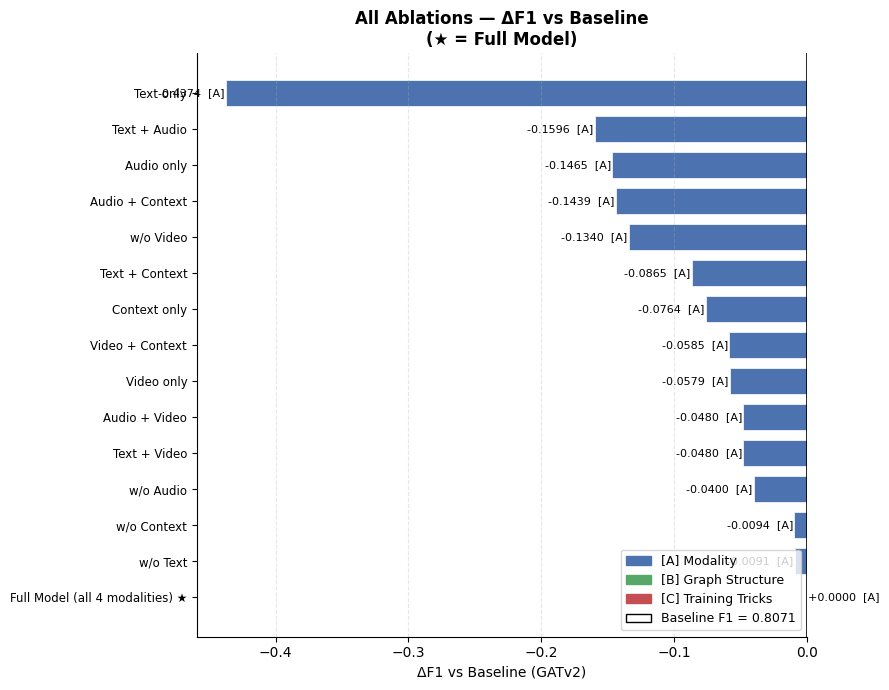


[Ablation Study Complete]


In [35]:
# ===============================
# 26. Ablation — ΔF1 Heatmap (all experiments)
#     Horizontal bar chart showing ΔF1 vs baseline
#     for every ablation configuration, coloured by group.
#     Saved to Google Drive as ablation_delta_heatmap.png
# ===============================

import matplotlib.patches as mpatches

GROUP_COLORS = {
    'A': '#4C72B0',
    'B': '#55A868',
    'C': '#C44E52'
}

GROUP_LABELS = {
    'A': 'Modality',
    'B': 'Graph Structure',
    'C': 'Training Tricks'
}

sorted_all = sorted(
    all_ablation_results,
    key=lambda x: x['f1'],
    reverse=True
)

names = [
    r['name'] + (' ★' if r['name'] == FULL_MODEL_KEY else '')
    for r in sorted_all
]

delta = [
    r['f1'] - BASELINE['f1']
    for r in sorted_all
]

colors = [
    GROUP_COLORS[r['group']]
    for r in sorted_all
]

grp_lbl = [
    f"[{r['group']}]"
    for r in sorted_all
]


# ── Create plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(9, max(7, len(sorted_all) * 0.40))
)

bars = ax.barh(
    range(len(names)),
    delta,
    color=colors,
    edgecolor='white',
    lw=0.5,
    height=0.72
)

ax.axvline(
    0,
    color='black',
    lw=1.2
)


# ── Add ΔF1 labels ────────────────────────────────────────────────────────────
for bar, val, grp in zip(
    bars,
    delta,
    grp_lbl
):
    xpos = (
        val + 0.001
        if val >= 0
        else val - 0.001
    )

    ha = (
        'left'
        if val >= 0
        else 'right'
    )

    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.4f}  {grp}",
        va='center',
        ha=ha,
        fontsize=8
    )


# ── Axis formatting ───────────────────────────────────────────────────────────
ax.set_yticks(
    range(len(names))
)

ax.set_yticklabels(
    names,
    fontsize=8.5
)

ax.set_xlabel(
    'ΔF1 vs Baseline (GATv2)',
    fontsize=10
)

ax.set_title(
    'All Ablations — ΔF1 vs Baseline\n(★ = Full Model)',
    fontweight='bold',
    fontsize=12
)

ax.grid(
    axis='x',
    alpha=0.3,
    ls='--'
)

ax.spines[
    ['top', 'right']
].set_visible(False)


# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(
        color=c,
        label=f"[{g}] {GROUP_LABELS[g]}"
    )
    for g, c in GROUP_COLORS.items()
]

baseline_patch = mpatches.Patch(
    color='white',
    ec='black',
    lw=1,
    label=f"Baseline F1 = {BASELINE['f1']:.4f}"
)

ax.legend(
    handles=legend_patches + [baseline_patch],
    fontsize=9,
    loc='lower right'
)


# ── Save figure ───────────────────────────────────────────────────────────────
plt.tight_layout()

try:
    path = os.path.join(
        BASE_PATH,
        'ablation_delta_heatmap.png'
    )

    plt.savefig(
        path,
        dpi=150,
        bbox_inches='tight'
    )

    print(
        "Saved → ablation_delta_heatmap.png"
    )

except Exception as e:
    print(
        f"[WARN] {e}"
    )

plt.show()

print("\n[Ablation Study Complete]")

  GROUP D — SPECTRAL DESCRIPTOR ABLATION (10 experiments)
  Seed : 150 | Baseline F1 : 0.8071

Loading HuBERT-large (one-time pass -- cached hidden states are reused by all 10 weight configurations below)...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Caching raw descriptors + HuBERT states: 100%|██████████| 690/690 [20:02<00:00,  1.74s/it]

Caching done in 20.0 min.

Running 10 experiments (9 re-weighted + 1 reused baseline)...

  [01/10] Full Model (all 4 spectral descriptors) ... 

F1=0.8071 (▲0.0000)
  [02/10] w/o Pitch (F0) ... F1=0.7778 (▼0.0292)
  [03/10] w/o Spectral Flux ... F1=0.7787 (▼0.0284)
  [04/10] w/o Spectral Centroid ... F1=0.7578 (▼0.0492)
  [05/10] w/o RMS Energy ... F1=0.7691 (▼0.0379)
  [06/10] Pitch (F0) only ... F1=0.7872 (▼0.0198)
  [07/10] Spectral Flux only ... F1=0.7205 (▼0.0865)
  [08/10] Spectral Centroid only ... F1=0.8074 (▲0.0004)
  [09/10] RMS Energy only ... F1=0.7691 (▼0.0379)
  [10/10] No FFT Guidance (uniform pooling) ... F1=0.7976 (▼0.0094)

Done in 2.6 min.

  D — SPECTRAL DESCRIPTOR ABLATION RESULTS
  Variant                                    Acc      F1    Prec     Rec     AUC       ΔF1
-----------------------------------------------------------------------------------------------
  [Baseline GATv2]                        0.8077  0.8071  0.8118  0.8077  0.8536       —
-----------------------------------------------------------------------------------------------
  Spectral Centroid only                  0.8077  0.8074  0.80

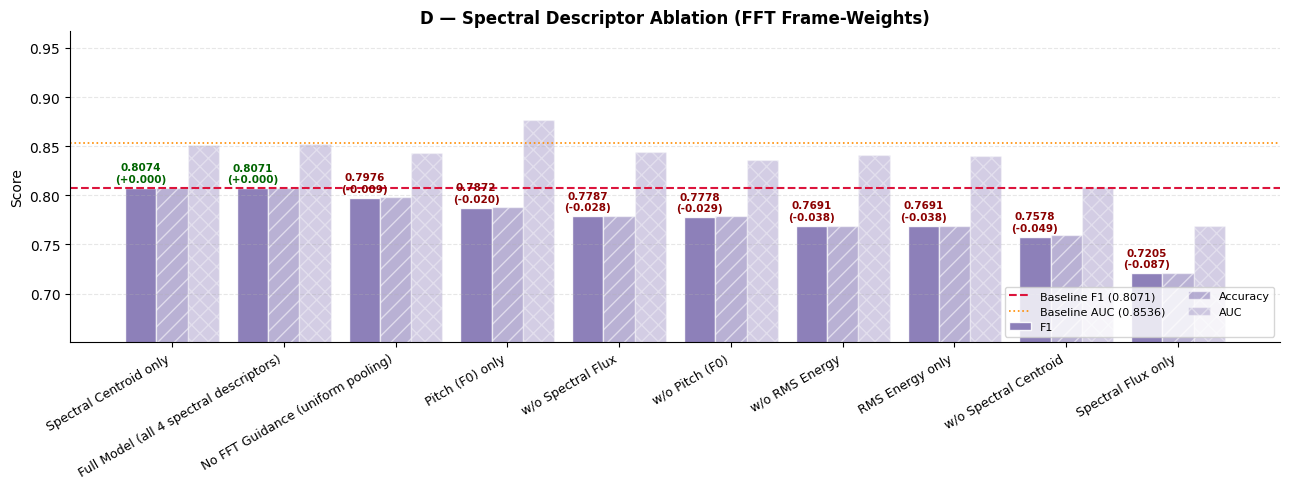


  KEY FINDINGS (Spectral Descriptors):
    Full model F1 (4 descriptors) : 0.8071
    Most critical descriptor      : w/o Spectral Centroid (removal drops F1 by 0.0492)
    Least critical                : w/o Spectral Flux (removal drops F1 by 0.0284)
    Best single descriptor        : Spectral Centroid only F1=0.8074
    No FFT guidance (uniform)     : F1=0.7976 (▼0.0094 vs full weighting)


In [36]:
# ===============================
# 27. Ablation D — Spectral Descriptor Ablation (FFT Frame-Weighting)
#     "Ablation studies on the importance of each of the 4 spectral
#      descriptors are desirable."
#
#     The 4 descriptors (Cell 5) are what drive get_sarcasm_frame_weights():
#       Pitch F0 (0.40) / Spectral flux (0.25) / Spectral centroid (0.20) /
#       RMS energy (0.15) -> softmax attention over HuBERT hidden states.
#     They only affect the 'focused' half of the 2048-d audio embedding
#     (utterance -> node 'audio'; context -> half of node 'context').
#     Ablating one means re-deriving that attention with its contribution
#     removed -- NOT zeroing an input dimension like Group A did.
#
#     10 experiments:
#       - Full (all 4 descriptors)                       [reuses cached .npy]
#       - Leave-one-out, remaining 3 renormalised to 1     (4 variants)
#       - Single descriptor only (weight = 1.0)            (4 variants)
#       - No FFT guidance at all (uniform attention = mean pooling)
#
#     One-time cost: a single HuBERT-large forward pass per utterance +
#     context clip (same cost as Cell 5's original extraction). Every
#     variant after that just re-weights the cached hidden states, so
#     all 10 train in roughly the time Group A took.
# ===============================
assert 'run_ablation' in dir(), "Run Cell 21 (Ablation Setup & Helpers) first."
assert 'SarcasmGATv2Tunable' in dir(), "Run Cell 18 (Optuna Objective & Study) first."

import os, time
import numpy as np
import torch, torch.nn.functional as F
import subprocess as sp
import tempfile
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data as _Data
from transformers import HubertModel, Wav2Vec2FeatureExtractor, logging as hf_logging
hf_logging.set_verbosity_error()

AUDIO_SAMPLE_RATE = 16_000  # HuBERT's expected rate -- hardcoded since Cell 5's
                             # RUN_EXTRACTION-local SAMPLE_RATE may be out of scope

# ── Reload straight from disk -- self-contained regardless of session state ────
sd_sample_ids     = np.load(os.path.join(BASE_PATH, IDS_FEAT))
sd_labels         = np.load(os.path.join(BASE_PATH, LABELS_FEAT))
sd_t_features     = np.load(os.path.join(BASE_PATH, TEXT_FEAT))
sd_v_features     = np.load(os.path.join(BASE_PATH, VIDEO_FEAT))
sd_video_ctx      = np.load(os.path.join(BASE_PATH, 'video_context_features.npy'))
sd_audio_utt_full = np.load(os.path.join(BASE_PATH, AUDIO_FEAT))          # all-4-descriptor
sd_audio_ctx_full = np.load(os.path.join(BASE_PATH, 'audio_context_features.npy'))

assert (len(sd_sample_ids) == len(sd_labels) == len(sd_t_features)
        == sd_audio_utt_full.shape[0] == sd_video_ctx.shape[0]), \
    "Row-count mismatch across cached feature files -- re-run Cells 5-8."

print("=" * 60)
print("  GROUP D — SPECTRAL DESCRIPTOR ABLATION (10 experiments)")
print(f"  Seed : {ABLATION_SEED} | Baseline F1 : {BASELINE['f1']:.4f}")
print("=" * 60)


# ── Step 1: waveform + raw (un-normalised) descriptor extraction ───────────────
def sd_extract_wav(video_path, sr=AUDIO_SAMPLE_RATE):
    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        tmp_path = tmp.name
    sp.run(['ffmpeg', '-y', '-i', video_path, '-ac', '1', '-ar', str(sr), '-vn', tmp_path],
           stdout=sp.DEVNULL, stderr=sp.DEVNULL, check=True)
    y, _ = librosa.load(tmp_path, sr=sr, mono=True)
    os.remove(tmp_path)
    return y.astype(np.float32)


def sd_raw_descriptors(y, sr=AUDIO_SAMPLE_RATE, hop_length=512):
    """F0, RMS, spectral flux, spectral centroid -- un-normalised, length-aligned."""
    try:
        f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr, hop_length=hop_length)
        f0 = np.nan_to_num(f0, nan=0.0)
    except Exception:
        f0 = np.zeros(1 + len(y) // hop_length)
    rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
    stft = np.abs(librosa.stft(y, hop_length=hop_length, n_fft=1024))
    flux = np.sqrt(np.sum(np.diff(stft, axis=1) ** 2, axis=0))
    flux = np.pad(flux, (1, 0))
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
    min_len = min(len(f0), len(rms), len(flux), len(centroid))
    return dict(f0=f0[:min_len], rms=rms[:min_len],
                flux=flux[:min_len], centroid=centroid[:min_len])


# ── Step 2: one-time HuBERT hidden-state caching (utterance + context) ─────────
print("\nLoading HuBERT-large (one-time pass -- cached hidden states are reused "
      "by all 10 weight configurations below)...")
sd_hubert_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
sd_hubert_model = HubertModel.from_pretrained(HUBERT_NAME).float().to(DEVICE).eval()


@torch.no_grad()
def sd_hidden_states(y, sr=AUDIO_SAMPLE_RATE):
    """Mean of last 4 HuBERT hidden layers -> (T_h, 1024), cached on CPU."""
    inp = sd_hubert_extractor(y, sampling_rate=sr, return_tensors='pt', padding=True)
    wav = inp['input_values'].to(DEVICE)
    out = sd_hubert_model(wav, output_hidden_states=True)
    last4 = torch.stack(out.hidden_states[-4:]).mean(0)  # (1, T_h, 1024)
    return last4[0].cpu().numpy()


sd_cache_utt, sd_cache_ctx = {}, {}
t0 = time.time()
for uid in tqdm(sd_sample_ids, desc='Caching raw descriptors + HuBERT states'):
    for cache, folder, suffix in [(sd_cache_utt, UTTERANCE_DIR, '.mp4'),
                                   (sd_cache_ctx, CONTEXT_DIR, '_c.mp4')]:
        path = os.path.join(folder, f'{uid}{suffix}')
        try:
            y = sd_extract_wav(path)
            cache[uid] = dict(raw=sd_raw_descriptors(y), hidden=sd_hidden_states(y))
        except Exception as e:
            print(f'[WARN] caching failed for {uid} ({folder}): {e}')
            cache[uid] = None
print(f"Caching done in {(time.time() - t0) / 60:.1f} min.")

del sd_hubert_model, sd_hubert_extractor
torch.cuda.empty_cache()


# ── Step 3: recombine cached descriptors -> score -> FFT-attention pooling ─────
def sd_norm01(x):
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 1e-8 else np.zeros_like(x)


def sd_combine(raw, weights):
    score = np.zeros_like(raw['f0'], dtype=np.float32)
    for k, w in weights.items():
        if w == 0:
            continue
        score = score + sd_norm01(raw[k]).astype(np.float32) * w
    return score


def sd_pool(entry, weights, max_frames=MAX_FRAMES):
    if entry is None:
        return np.zeros(2048, dtype=np.float32)
    score = sd_combine(entry['raw'], weights)
    score = (score[:max_frames] if len(score) >= max_frames
             else np.pad(score, (0, max_frames - len(score))))
    hidden = torch.tensor(entry['hidden'], dtype=torch.float32, device=DEVICE)  # (T_h, 1024)
    T_h = hidden.shape[0]
    w_t = torch.tensor(score, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(0)
    w_aligned = F.interpolate(w_t, size=T_h, mode='linear', align_corners=False).squeeze()
    attn = torch.softmax(w_aligned * FFT_TEMP, dim=0)
    focused = (hidden * attn.unsqueeze(-1)).sum(0)
    global_ = hidden.mean(0)
    return torch.cat([focused, global_]).cpu().numpy()


def sd_build_features(weights):
    a = np.zeros((len(sd_sample_ids), 2048), dtype=np.float32)
    c_audio = np.zeros((len(sd_sample_ids), 2048), dtype=np.float32)
    for i, uid in enumerate(sd_sample_ids):
        a[i] = sd_pool(sd_cache_utt.get(uid), weights)
        c_audio[i] = sd_pool(sd_cache_ctx.get(uid), weights)
    c = np.concatenate([c_audio, sd_video_ctx], axis=1)
    return a, c


# ── Step 4: the 10 weight configurations ────────────────────────────────────────
BASE_W = dict(f0=0.40, flux=0.25, centroid=0.20, rms=0.15)
DESC_NAMES = dict(f0='Pitch (F0)', flux='Spectral Flux',
                   centroid='Spectral Centroid', rms='RMS Energy')


def sd_renorm_without(key):
    remaining = {k: v for k, v in BASE_W.items() if k != key}
    total = sum(remaining.values())
    return {k: (remaining[k] / total if k in remaining else 0.0) for k in BASE_W}


def sd_single_only(key):
    return {k: (1.0 if k == key else 0.0) for k in BASE_W}


FULL_MODEL_KEY_D = "Full Model (all 4 spectral descriptors)"
experiments_D = [(FULL_MODEL_KEY_D, None)]
experiments_D += [(f"w/o {DESC_NAMES[k]}", sd_renorm_without(k)) for k in BASE_W]
experiments_D += [(f"{DESC_NAMES[k]} only", sd_single_only(k)) for k in BASE_W]
experiments_D += [("No FFT Guidance (uniform pooling)", {k: 0.0 for k in BASE_W})]


# ── Step 5: Data list + split (mirrors Cell 9 / Cell 18 exactly) ───────────────
def sd_make_loaders(a_feat, c_feat):
    dlist = []
    for i in range(len(sd_labels)):
        ei = torch.tensor([
            [0, 1], [1, 0], [0, 2], [2, 0], [1, 2], [2, 1],
            [3, 0], [0, 3], [3, 1], [1, 3], [3, 2], [2, 3],
            [0, 0], [1, 1], [2, 2], [3, 3]
        ], dtype=torch.long).t().contiguous()
        d = _Data(edge_index=ei, y=torch.tensor([sd_labels[i]], dtype=torch.float))
        d.text = torch.tensor(sd_t_features[i], dtype=torch.float).unsqueeze(0)
        d.audio = torch.tensor(a_feat[i], dtype=torch.float).unsqueeze(0)
        d.video = torch.tensor(sd_v_features[i], dtype=torch.float).unsqueeze(0)
        d.context = torch.tensor(c_feat[i], dtype=torch.float).unsqueeze(0)
        d.num_nodes = 4
        dlist.append(d)
    tv, ts = train_test_split(dlist, test_size=0.15, random_state=42, stratify=sd_labels)
    lbtv = np.array([d.y.item() for d in tv])
    tr, vl = train_test_split(tv, test_size=0.1765, random_state=42, stratify=lbtv)
    return _loaders(tr, vl, ts)


# ── Step 6: run all 10 experiments ──────────────────────────────────────────────
spectral_results = []
print(f"\nRunning {len(experiments_D)} experiments "
      f"({len(experiments_D) - 1} re-weighted + 1 reused baseline)...\n")
t0 = time.time()
for idx, (name, weights) in enumerate(experiments_D):
    print(f"  [{idx + 1:02d}/{len(experiments_D)}] {name} ...", end=" ", flush=True)
    if weights is None:
        a_feat = sd_audio_utt_full
        c_feat = np.concatenate([sd_audio_ctx_full, sd_video_ctx], axis=1)
    else:
        a_feat, c_feat = sd_build_features(weights)
    tr_dl, vl_dl, ts_dl = sd_make_loaders(a_feat, c_feat)
    r = run_ablation(name, tr_dl, vl_dl, ts_dl)
    r['group'] = 'D'
    spectral_results.append(r)
    all_ablation_results.append(r)
    df = r['f1'] - BASELINE['f1']
    sym = '▲' if df >= 0 else '▼'
    print(f"F1={r['f1']:.4f} ({sym}{abs(df):.4f})")
print(f"\nDone in {(time.time() - t0) / 60:.1f} min.")

# ── Table ────────────────────────────────────────────────────────────────────
print_table(spectral_results, "D — SPECTRAL DESCRIPTOR ABLATION RESULTS")

# ── Plot (extends GROUP_COLORS/LABELS so a re-run of Cell 26 picks up Group D) ──
if 'GROUP_COLORS' not in dir():
    GROUP_COLORS = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52'}
    GROUP_LABELS = {'A': 'Modality', 'B': 'Graph Structure', 'C': 'Training Tricks'}
GROUP_COLORS['D'] = '#8172B2'
GROUP_LABELS['D'] = 'Spectral Descriptors'

plot_group(spectral_results, "D — Spectral Descriptor Ablation (FFT Frame-Weights)",
           GROUP_COLORS['D'], 'ablation_spectral_delta.png')

# ── Findings ─────────────────────────────────────────────────────────────────
full_d = next(r for r in spectral_results if r['name'] == FULL_MODEL_KEY_D)
wout = [r for r in spectral_results if r['name'].startswith('w/o')]
single = [r for r in spectral_results if r['name'].endswith('only')]
uniform = next(r for r in spectral_results if r['name'].startswith('No FFT'))
most_critical = min(wout, key=lambda x: x['f1'])
least_critical = max(wout, key=lambda x: x['f1'])
best_single = max(single, key=lambda x: x['f1'])

print()
print("  KEY FINDINGS (Spectral Descriptors):")
print(f"    Full model F1 (4 descriptors) : {full_d['f1']:.4f}")
print(f"    Most critical descriptor      : {most_critical['name']} "
      f"(removal drops F1 by {full_d['f1'] - most_critical['f1']:.4f})")
print(f"    Least critical                : {least_critical['name']} "
      f"(removal drops F1 by {full_d['f1'] - least_critical['f1']:.4f})")
print(f"    Best single descriptor        : {best_single['name']} F1={best_single['f1']:.4f}")
print(f"    No FFT guidance (uniform)     : F1={uniform['f1']:.4f} "
      f"({'▲' if uniform['f1'] >= full_d['f1'] else '▼'}"
      f"{abs(uniform['f1'] - full_d['f1']):.4f} vs full weighting)")